In [110]:
# IMPORT LIBRARIES

#%matplotlib widget
import os
import glob

import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import pyleoclim as pyleo


from mpl_toolkits.basemap import Basemap

##### Data for FIgure 1 plot: 
(code for this lives at the end of this page)
https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-single-levels-monthly-means?tab=overview
> used CAPE, Convective precipitation, Total Precipitation and Wind Speed data (1940-2023)
> extracted subregion : 20 - 0 N and 10 W - 130 E
> Data lives in the External Hardrive
> https://dwikita-ichsana.medium.com/meteorology-101-how-to-plot-wind-map-e43c196edce8

In [111]:
### DIRECTORY PATHS #####
cave_path = 'Data/Caves/' 
inst_path = 'Data/Instrumental/'
save_path = 'Figures/GRL_Figures/'

#### SITE NAMES ####
P_site_name = [ 'chocfountain_stalagmate.csv', 'stumpy_stalagmate.csv', 
             'twins_stalagmate.csv', 'goblin_stalagmate.csv', 
             'chocfountain_hobo.csv', 'Stumpy_hobo.csv', 'goblin_hobo.csv', 'Vaisala.csv' ]


B_site_name = [ 'stal_slow.csv','stal_fast.csv', 'hobo_entrance.csv', 
               'hobo_interior.csv','Vaisala_Bulacan_.csv'  ]

#### WEATHER STATION SITES ###### 
weather_sites = [ 'CLSU.csv', 'Puerto.csv','Coron.csv','Aparri.csv' ]
# Coron weather station data is in the same climate type as Sabang. Hence using that over Puerto City.

def cave_daily( cave_name, site_name ):
    ''''
        This function reads drip rate data and converts it to daily data
        Input = cave name and associated cave site, raw drip rate
        Output= Daily time and daily drip rate in units of ml/min
        
    '''
    df_path    = os.path.join( cave_path, cave_name, site_name)
    df         = pd.read_csv( df_path )
    df.dropna( subset=['Time'], inplace=True )
    df['Time'] = pd.to_datetime( df['Time'], format = '%m/%d/%y %H:%M' )
    df.set_index( 'Time', inplace = True )
    df_daily   = df.resample('D').mean().reset_index( names = 'Date' )
    return df_daily

def inst_data(station):
    '''
    Functioon reads in daily weather station data from the Philippines
    input = raw weather station data closest to cave and in the same climate type
    output = parsed out daily data for variables: precip, temp, pressure, wind speed, wind direction
    '''
    inst    = os.path.join( inst_path,station)
    df_inst = pd.read_csv( inst, na_values=['-999'], parse_dates = { 'Date': ['YEAR', 'MONTH','DAY'] } )
    return df_inst



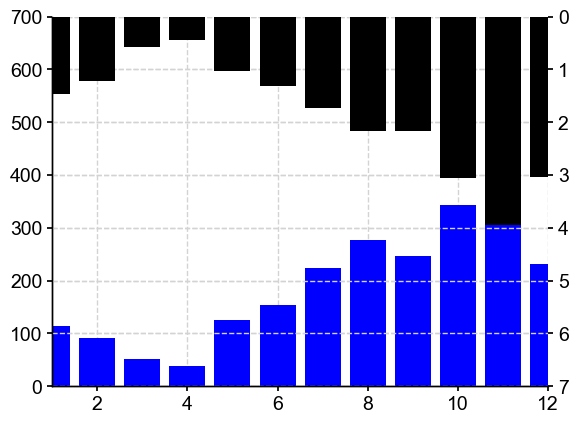

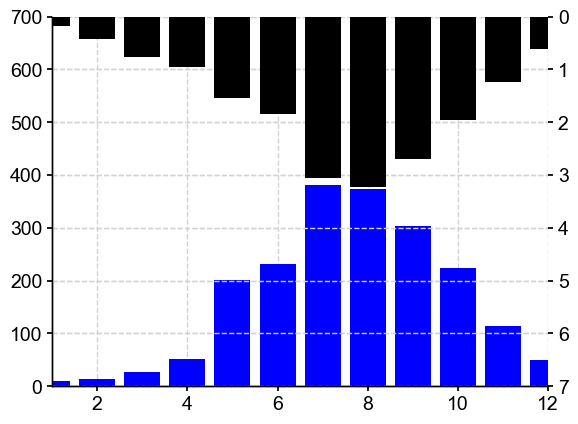

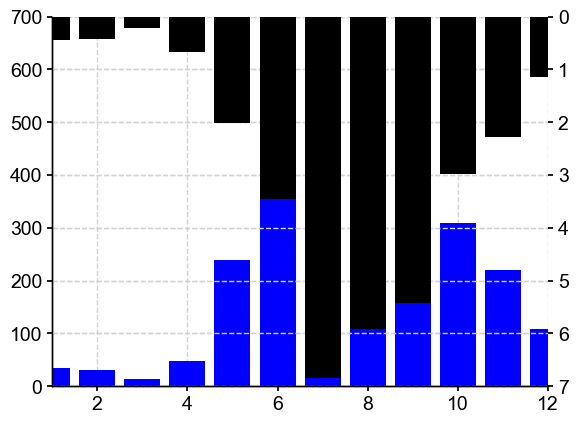

In [5]:
### PLOTTING EFFECTIVE RECHARGE DATA  #####

##### !!!!!! FOR APARRI !!!!! #######
aet_aparri = pd.read_csv('Data/Instrumental/Terra/AET-Aparri.csv')
aet_aparri['Time'] = pd.to_datetime( aet_aparri['Time'], format = '%m/%d/%y' )
gr_aet_aparri = aet_aparri.groupby(aet_aparri.Time.dt.month)['AET'].mean()

pt_aparri = pd.read_csv('Data/Instrumental/Terra/PT-Aparri.csv')
pt_aparri['Time'] = pd.to_datetime( pt_aparri['Time'], format = '%m/%d/%y' )
gr_pt_aparri = pt_aparri.groupby( pt_aparri.Time.dt.month )['Prcp'].mean()

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.bar( gr_pt_aparri.index, gr_pt_aparri.values, color='b' )
ax1.set( xlim =(1, 12), ylim =(0, 700) ) 
ax2.bar( gr_pt_aparri.index, gr_pt_aparri.values/gr_aet_aparri.values, color='k' )
ax2.set_ylim(0, 7) 
ax2.invert_yaxis()

plt.savefig(os.path.join(save_path, 'aparri_aet_pt3.eps'))
plt.show()

##### !!!!!! FOR CLSU !!!!! #######
aet_clsu = pd.read_csv('Data/Instrumental/Terra/AET-CLSU.csv')
aet_clsu['Time'] = pd.to_datetime( aet_clsu['Time'], format = '%m/%d/%y' )
gr_aet_clsu = aet_clsu.groupby(aet_clsu.Time.dt.month)['AET'].mean()

pt_clsu = pd.read_csv('Data/Instrumental/Terra/PT-CLSU.csv')
pt_clsu['Time'] = pd.to_datetime( pt_clsu['Time'], format = '%m/%d/%y' )
gr_pt_clsu = pt_clsu.groupby( pt_clsu.Time.dt.month )['Prcp'].mean()

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.bar( gr_pt_clsu.index, gr_pt_clsu.values, color='b' )
ax1.set( xlim =(1, 12), ylim =(0, 700) ) 
ax2.bar( gr_pt_clsu.index, gr_pt_clsu.values/gr_aet_clsu.values, color='k' )
ax2.set_ylim( 0, 7) 
ax2.invert_yaxis()

plt.savefig(os.path.join(save_path, 'clsu_aet_pt3.eps'))
plt.show()

##### !!!!!! FOR CORON !!!!! #######
aet_coron = pd.read_csv('Data/Instrumental/Terra/AET-Coron.csv')
aet_coron['Time'] = pd.to_datetime( aet_coron['Time'], format = '%m/%d/%y' )
gr_aet_coron = aet_coron.groupby(aet_coron.Time.dt.month)['AET'].mean()

pt_coron = pd.read_csv('Data/Instrumental/Terra/PT-Coron.csv')
pt_coron['Time'] = pd.to_datetime( pt_coron['Time'], format = '%m/%d/%y' )
gr_pt_coron = pt_coron.groupby( pt_coron.Time.dt.month )['Prcp'].mean()

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.bar( gr_pt_coron.index, gr_pt_coron.values, color='b' )
ax1.set( xlim =(1, 12), ylim =(0, 700) ) 
ax2.bar( gr_pt_coron.index, gr_pt_coron.values/gr_aet_coron.values, color='k' )
ax2.set_ylim( 0, 7) 
ax2.invert_yaxis()

plt.savefig(os.path.join(save_path, 'coron_aet_pt3.eps'))
plt.show()

NameError: name 'aet_coron' is not defined

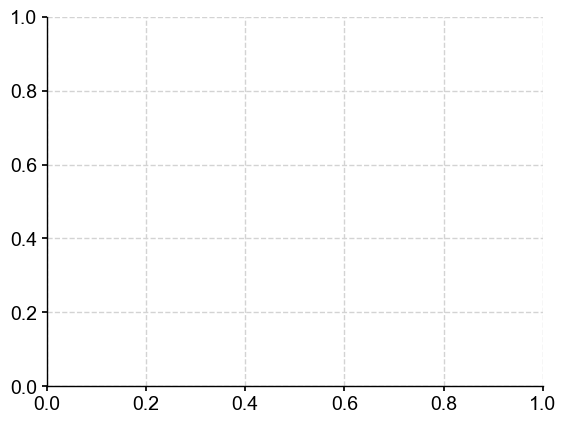

In [112]:
##### TIME SERIES FOR EFFECTIVE RECHARFGE FOR THE THREE WEATHER STATION ######
fig, ax = plt.subplots()
ax.plot(aet_coron['Time'][408:505],pt_coron['Prcp'][408:505]/aet_coron['AET'][408:505])
ax.plot(aet_clsu['Time'][408:505],pt_clsu['Prcp'][408:505]/aet_clsu['AET'][408:505], color='k' )
ax.plot(aet_aparri['Time'][408:505],pt_aparri['Prcp'][408:505]/aet_aparri['AET'][408:505])
#ax.set_xticks(pd.date_range(start="2018-01-01", end="2023-12-31", freq="M"))
plt.savefig(os.path.join(save_path, 'timeseries_aet_pt.eps'))
plt.show()

In [113]:
### WEATHER STATION DATA #####
df_clsu   = inst_data(weather_sites[0])
df_clsu_LP = df_clsu['PRESSURE'].mean() - 2*( df_clsu['PRESSURE'].std() )
print(f'At the 95th percentile for CLSU : {df_clsu_LP}' )
df_puerto = inst_data(weather_sites[1])
df_puerto_LP = df_puerto['PRESSURE'].mean() - 2*( df_puerto['PRESSURE'].std() )
print(f'At the 95th percentile for Palawan : {df_puerto_LP}' )
#### FOR PALAWAN, USE CORON, SAME CLIMATE TYPE
df_coron = inst_data(weather_sites[2])
df_coron_LP = df_coron['PRESSURE'].mean() - 2*( df_coron['PRESSURE'].std() )
print(f'At the 95th percentile for Coron : {df_coron_LP}' )
df_aparri = inst_data(weather_sites[3])
df_aparri_LP = df_aparri['PRESSURE'].mean() - 2*( df_aparri['PRESSURE'].std() )
print(f'At the 95th percentile for Aparri : {df_aparri_LP}' )

###### DAILY CAVE DATA #########
### Puerto Princesa ###
'Drip Rate'
df_cf_daily     = cave_daily('Palawan', P_site_name[0])
df_stumpy_daily = cave_daily('Palawan', P_site_name[1])
df_twins_daily  = cave_daily('Palawan', P_site_name[2])
df_goblin_daily = cave_daily('Palawan', P_site_name[3])
'Cave-Air Temperature'
df_chocf_daily  = cave_daily('Palawan', P_site_name[4])
df_st_daily     = cave_daily('Palawan', P_site_name[5])
df_gob_daily    = cave_daily('Palawan', P_site_name[6])
'Cave-Air CO2'
df_pal_co2_daily= cave_daily('Palawan', P_site_name[7])

### Biak-Na-Bato/Bulacan ###
'Drip Rate'
df_slow_daily = cave_daily('Bulacan', B_site_name[0])
df_fast_daily = cave_daily('Bulacan', B_site_name[1])
'Cave-Air Temperature'
df_entra_daily= cave_daily('Bulacan', B_site_name[2])
df_inte_daily = cave_daily('Bulacan', B_site_name[3])
'Cave-Air CO2'
df_bnb_co2_daily=cave_daily('Bulacan', B_site_name[4])

At the 95th percentile for CLSU : 996.0728404656647
At the 95th percentile for Palawan : 1004.9771817352038
At the 95th percentile for Coron : 999.0497188324032
At the 95th percentile for Aparri : 1002.1971221431735


In [129]:
# For KARSTOLUTION GETTING MONTHLY DATA

# PCO2 monthly data #
display( df_bnb_co2_daily.dtypes )
df_bnb_co2_daily['date'] = pd.to_datetime(df_bnb_co2_daily['Date'])
df_bnb_co2_daily = df_bnb_co2_daily.set_index('date')
co2_monthly = df_bnb_co2_daily.resample('M').mean()

# Cave Temp monthly data #
display( df_inte_daily.dtypes )
df_inte_daily['date'] = pd.to_datetime(df_inte_daily['Date'])
df_inte_daily = df_inte_daily.set_index('date')
temp_monthly  = df_inte_daily.resample('M').mean()


Date    datetime64[ns]
CO2            float64
dtype: object

Date             datetime64[ns]
Interior_Temp           float64
dtype: object

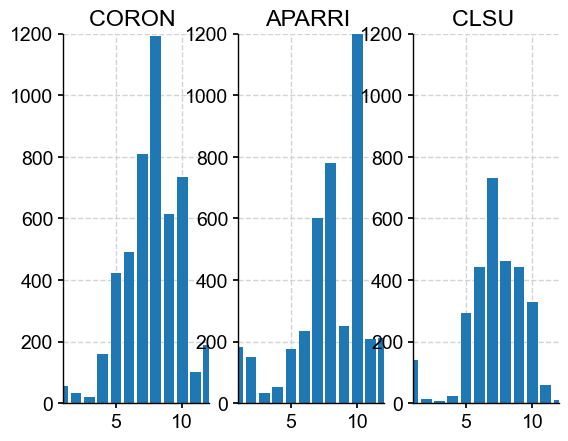

In [10]:
##### WEATHER STATION COLLATED TO MONTHLY DATA AND PLOTTED.  #######
df_coron_clima = df_coron.groupby(df_coron.Date.dt.month)['RAINFALL'].sum()
df_aparri_clima= df_aparri.groupby(df_aparri.Date.dt.month)['RAINFALL'].sum()
df_clsu_clima  = df_clsu.groupby(df_clsu.Date.dt.month)['RAINFALL'].sum()
### PLOT OF THE MONTHLY CLIMATOLOGIES ####
plt.subplot(1, 3, 1) 
plt.bar(df_coron_clima.index, df_coron_clima.values)
plt.xlim(1, 12) 
plt.ylim(0, 1200) 
plt.title('CORON ')
plt.subplot(1, 3, 2)
plt.bar(df_aparri_clima.index, df_aparri_clima.values)
plt.xlim(1, 12) 
plt.ylim(0, 1200)
plt.title('APARRI ')
plt.subplot(1, 3, 3)
plt.bar(df_clsu_clima.index, df_clsu_clima.values)
plt.xlim(1, 12) 
plt.ylim(0, 1200)
plt.title('CLSU ')
plt.show()

/var/folders/cm/syqd5kfn0xl_t2hqr3m3szhc0000gn/T/ipykernel_55550/847028209.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  c = ax.scatter(theta, r, c=values,  s=30, vmin = 0 , vmax = values.max() ,cmap=plt.cm.get_cmap('RdBu_r', 10) ,alpha=0.85)


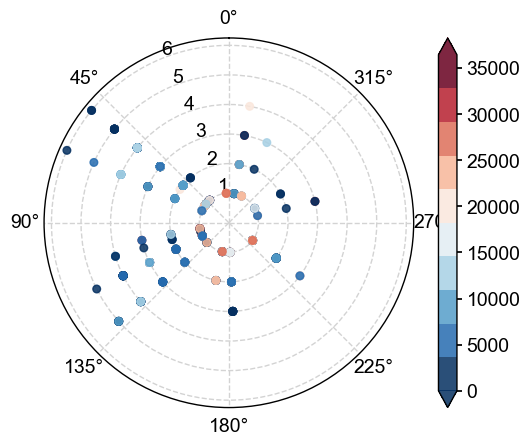

In [49]:
# POLAR PROJECTION 
r     = df_clsu['WIND_SPEED'][222:719]
theta = df_clsu['WIND_DIRECTION'][222:719] # OVERLAP with CO2
values= df_bnb_co2_daily['CO2']

# Compute areas and colors
colors = values
# orig_map=plt.cm.get_cmap('PuBu_r') 
  
# reversing the original colormap using reversed() function 
reversed_map = orig_map.reversed() 

fig = plt.figure()
ax = fig.add_subplot(111, projection='polar')
#c = ax.scatter(theta, r, c=values,  s=30, vmin = 0 , vmax = values.max() ,cmap='RdBu_r' ,alpha=0.85)
c = ax.scatter(theta, r, c=values,  s=30, vmin = 0 , vmax = values.max() ,cmap=plt.cm.get_cmap('RdBu_r', 10) ,alpha=0.85)
ax.set_theta_zero_location("N")
fig.colorbar(c, extend = 'both')
plt.savefig(os.path.join(save_path, 'Wind_Rose_V2.eps'))

In [130]:
#### CREATING A FUNCTION THAT ISOLATES WHEN IT RAINED SIGNIFICANTLY.   ### 
def clsu_pressure_events ():
    ax1.axvline(x= df_clsu['Date'][179], color='r', linestyle='-')
    ax1.axvline(x= df_clsu['Date'][233], color='r', linestyle='-')
    ax1.axvline(x= df_clsu['Date'][267], color='r', linestyle='-')
    ax1.axvline(x= df_clsu['Date'][287], color='r', linestyle='-')
    ax1.axvline(x= df_clsu['Date'][301], color='r', linestyle='-')
    ax1.axvline(x= df_clsu['Date'][514], color='r', linestyle='-')
    ax1.axvline(x= df_clsu['Date'][559], color='r', linestyle='-')
    ax1.axvline(x= df_clsu['Date'][570], color='r', linestyle='-')
    ax1.axvline(x= df_clsu['Date'][603], color='r', linestyle='-')
    ax1.axvline(x= df_clsu['Date'][609], color='r', linestyle='-')
    return 

def coron_pressure_events ():
    ax1.axvline(x= df_coron['Date'][179], color='r', linestyle='-')
    ax1.axvline(x= df_coron['Date'][267], color='r', linestyle='-')
    ax1.axvline(x= df_coron['Date'][301], color='r', linestyle='-')
    ax1.axvline(x= df_coron['Date'][342], color='r', linestyle='-')
    ax1.axvline(x= df_coron['Date'][355], color='r', linestyle='-')
    ax1.axvline(x= df_coron['Date'][379], color='r', linestyle='-')
    ax1.axvline(x= df_coron['Date'][604], color='r', linestyle='-')
    return 

(19216.0, 19711.0)

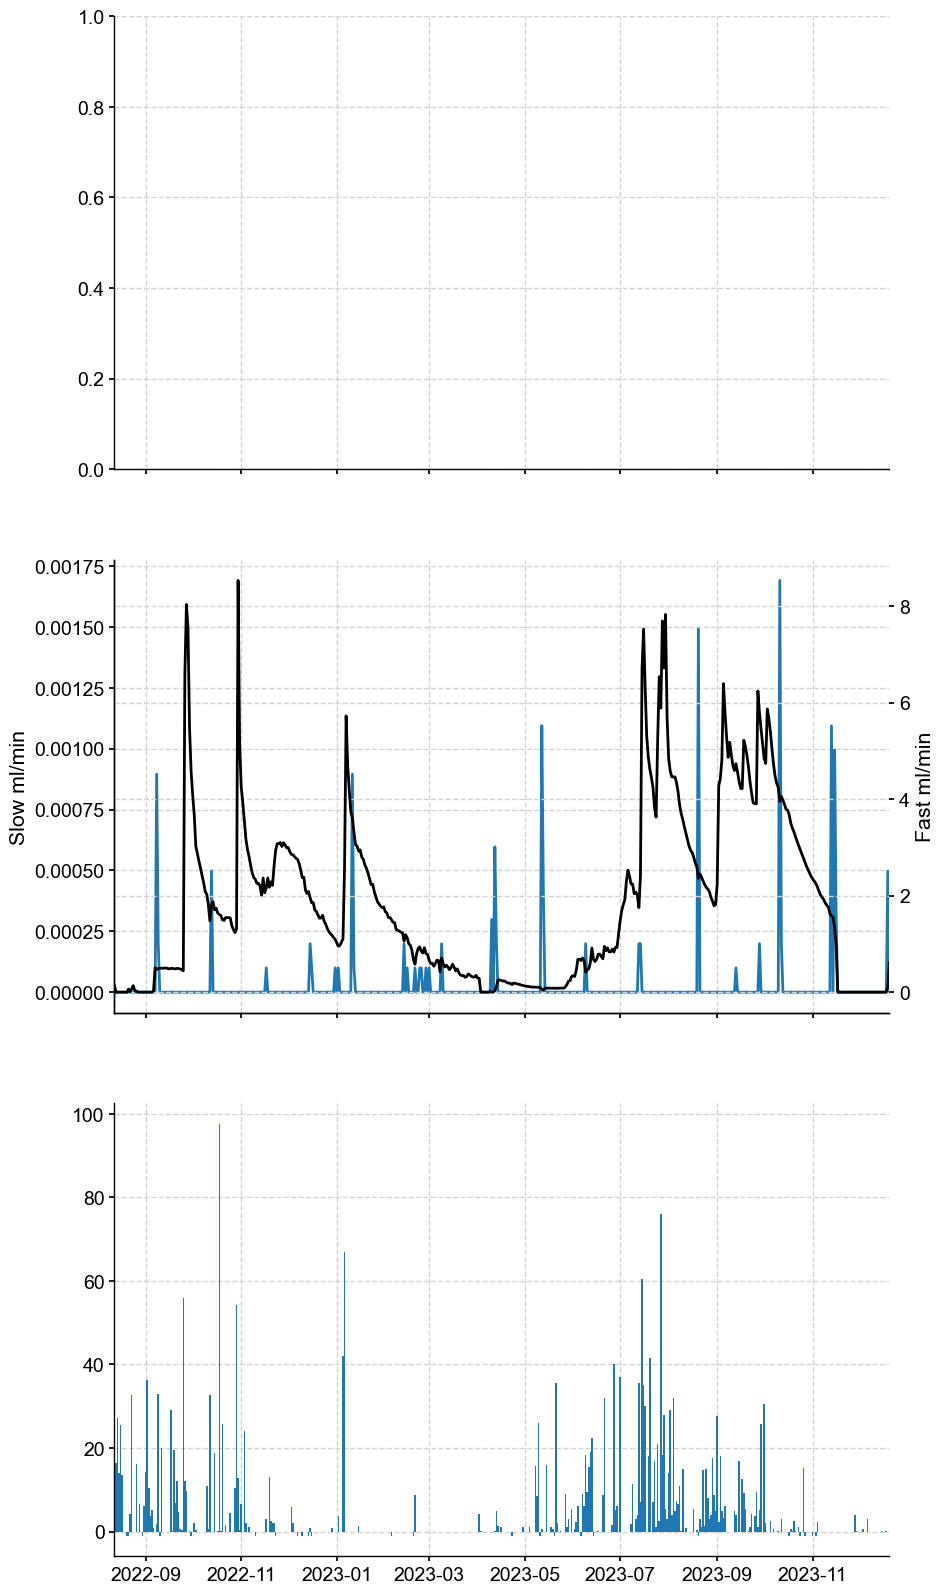

In [131]:
### SIMPLE FIGURE DRIP RATE AND WEATHER STATION DATA FOR BIAK NA BATO ###
f, (ax1, ax3, ax5) = plt.subplots( 3, 1, figsize = (10,20), sharex = True ) 
ax3.plot( df_slow_daily['Date'], df_slow_daily['slow_ml/min'] )
#ax3.set_yscale('log')
ax3.set_ylabel('Slow ml/min')
ax4 = ax3.twinx()
ax4.plot( df_fast_daily['Date'], df_fast_daily['fast_ml/min'], 'k')
ax4.set_ylabel('Fast ml/min')
ax5.bar( df_clsu['Date'], df_clsu['RAINFALL'], width = 1 )

ax5.set_xlim( [ df_clsu['Date'][223], df_clsu['Date'][718] ] )
#plt.savefig(os.path.join(save_path, 'BNB_V3.eps'))

(19216.0, 19711.0)

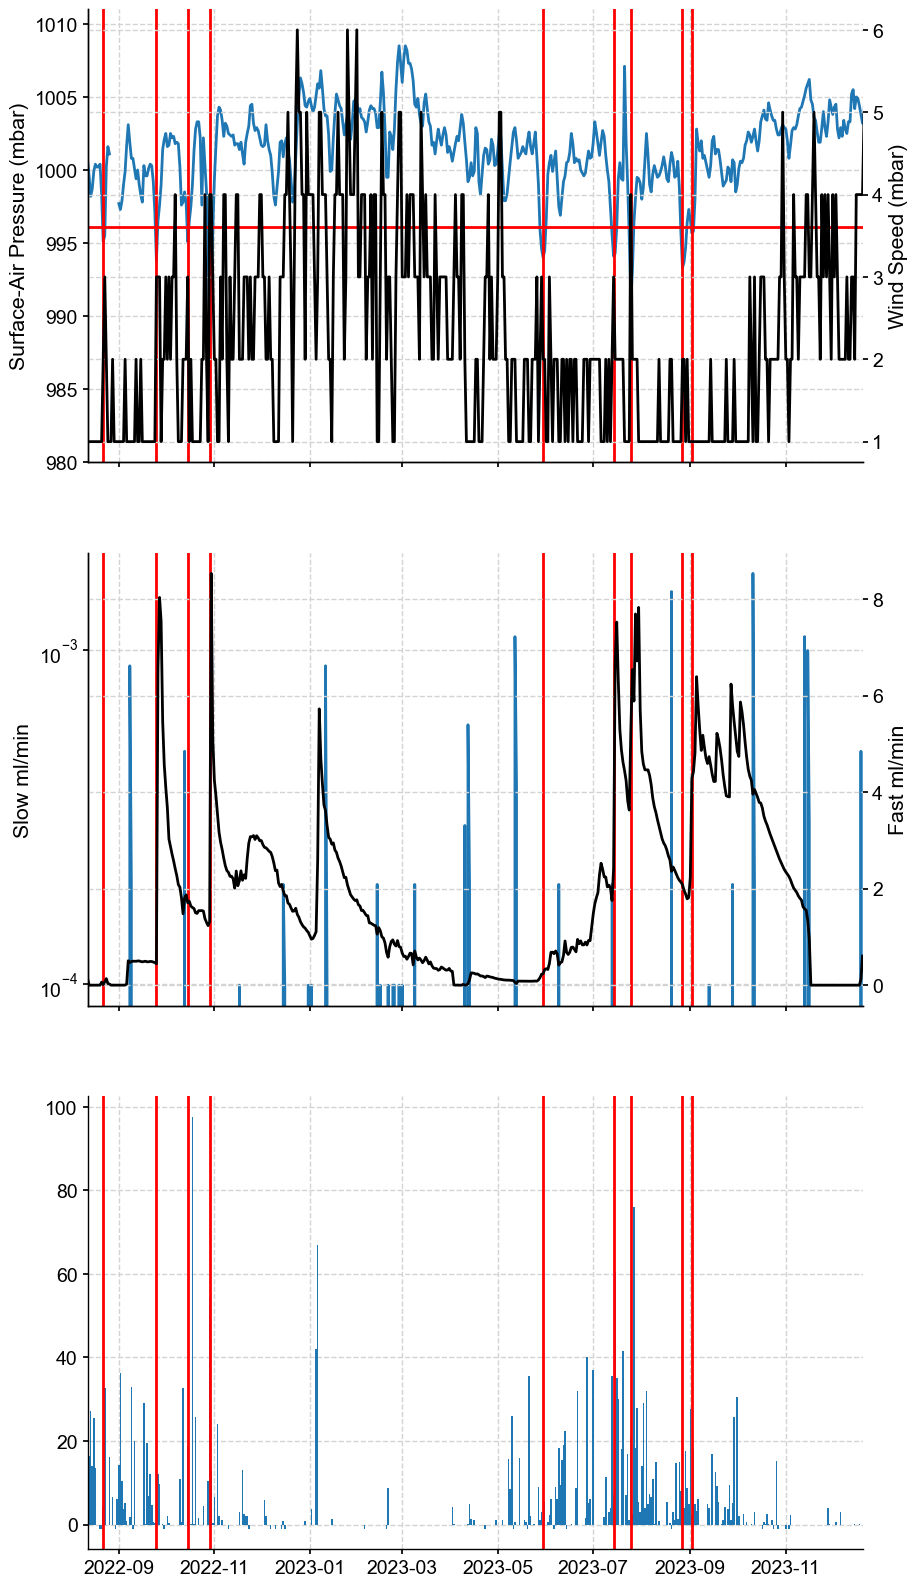

In [132]:
### FIGURE DRIP RATE AND WEATHER STATION DATA FOR BIAK NA BATO ###
### with known low pressure events as vertical lines ###
f, (ax1, ax3, ax5) = plt.subplots( 3, 1, figsize = (10,20), sharex = True ) 
ax1.plot( df_clsu['Date'], df_clsu['PRESSURE'])
ax1.axhline(y=df_clsu_LP, color='r', linestyle='-')
ax1.axvline(x= df_clsu['Date'][179], color='r', linestyle='-')
ax1.axvline(x= df_clsu['Date'][233], color='r', linestyle='-')
ax1.axvline(x= df_clsu['Date'][267], color='r', linestyle='-')
ax1.axvline(x= df_clsu['Date'][287], color='r', linestyle='-')
ax1.axvline(x= df_clsu['Date'][301], color='r', linestyle='-')
ax1.axvline(x= df_clsu['Date'][514], color='r', linestyle='-')
ax1.axvline(x= df_clsu['Date'][559], color='r', linestyle='-')
ax1.axvline(x= df_clsu['Date'][570], color='r', linestyle='-')
ax1.axvline(x= df_clsu['Date'][603], color='r', linestyle='-')
ax1.axvline(x= df_clsu['Date'][609], color='r', linestyle='-')
ax1.set_ylabel('Surface-Air Pressure (mbar)')
ax1.set_ylim( [980, 1011] )
ax1.set_xlim( [ df_clsu['Date'][223], df_clsu['Date'][718] ] )
# SEPTEMBER 01 2022 till DECEMBER 31 2023 #
ax2 = ax1.twinx()
ax2.plot( df_clsu['Date'], df_clsu['WIND_SPEED'], 'k')
ax2.set_ylabel('Wind Speed (mbar)')
ax3.plot( df_slow_daily['Date'], df_slow_daily['slow_ml/min'] )
ax3.axvline(x= df_clsu['Date'][179], color='r', linestyle='-')
ax3.axvline(x= df_clsu['Date'][233], color='r', linestyle='-')
ax3.axvline(x= df_clsu['Date'][267], color='r', linestyle='-')
ax3.axvline(x= df_clsu['Date'][287], color='r', linestyle='-')
ax3.axvline(x= df_clsu['Date'][301], color='r', linestyle='-')
ax3.axvline(x= df_clsu['Date'][514], color='r', linestyle='-')
ax3.axvline(x= df_clsu['Date'][559], color='r', linestyle='-')
ax3.axvline(x= df_clsu['Date'][570], color='r', linestyle='-')
ax3.axvline(x= df_clsu['Date'][603], color='r', linestyle='-')
ax3.axvline(x= df_clsu['Date'][609], color='r', linestyle='-')
ax3.set_yscale('log')
ax3.set_ylabel('Slow ml/min')
#####
ax4 = ax3.twinx()
ax4.plot( df_fast_daily['Date'], df_fast_daily['fast_ml/min'], 'k')
ax4.set_ylabel('Fast ml/min')
ax5.bar( df_clsu['Date'], df_clsu['RAINFALL'], width = 1 )
ax5.axvline(x= df_clsu['Date'][179], color='r', linestyle='-')
ax5.axvline(x= df_clsu['Date'][233], color='r', linestyle='-')
ax5.axvline(x= df_clsu['Date'][267], color='r', linestyle='-')
ax5.axvline(x= df_clsu['Date'][287], color='r', linestyle='-')
ax5.axvline(x= df_clsu['Date'][301], color='r', linestyle='-')
ax5.axvline(x= df_clsu['Date'][514], color='r', linestyle='-')
ax5.axvline(x= df_clsu['Date'][559], color='r', linestyle='-')
ax5.axvline(x= df_clsu['Date'][570], color='r', linestyle='-')
ax5.axvline(x= df_clsu['Date'][603], color='r', linestyle='-')
ax5.axvline(x= df_clsu['Date'][609], color='r', linestyle='-')
ax5.set_xlim( [ df_clsu['Date'][223], df_clsu['Date'][718] ] )
#plt.savefig(os.path.join(save_path, 'BNB_V2.eps'))

(19168.0, 19722.0)

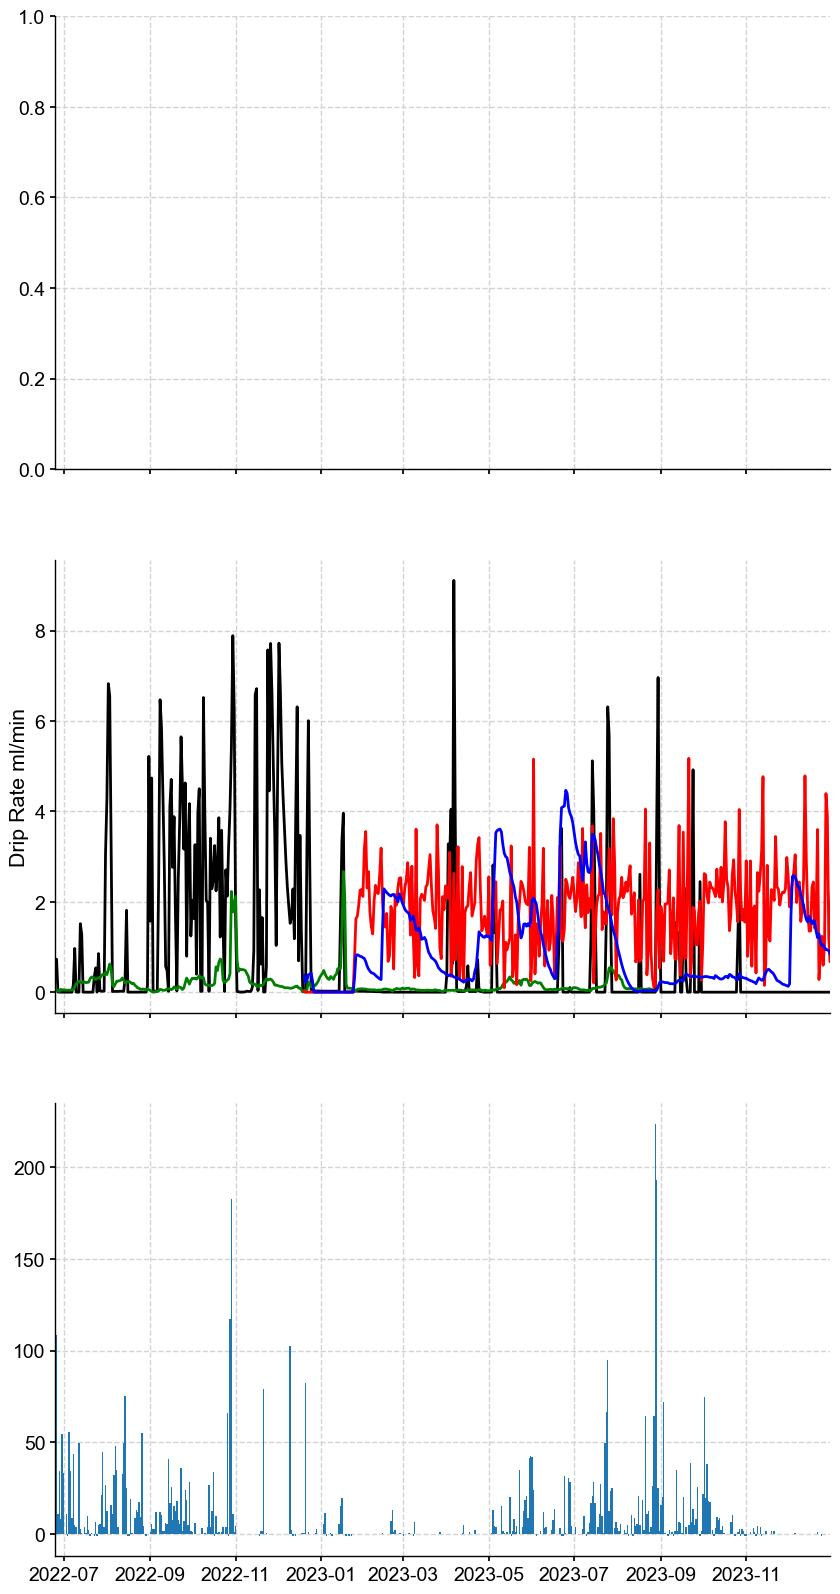

In [133]:
### FIGURE DRIP RATE AND WEATHER STATION DATA FOR PUERTO PRINCESA ###
f, (ax1, ax3, ax5) = plt.subplots( 3, 1, figsize = (10,20), sharex = True ) 
ax3.plot( df_cf_daily['Date'], df_cf_daily['cf_ml/min'], 'k')
ax3.plot( df_stumpy_daily['Date'], df_stumpy_daily['stumpy_ml/min'], 'g')
ax3.plot( df_twins_daily['Date'], df_twins_daily['twins_ml/min'], 'r')
ax3.plot( df_goblin_daily['Date'], df_goblin_daily['goblin_ml/min'], 'b')
ax3.set_ylabel('Drip Rate ml/min')

ax5.bar( df_coron['Date'], df_coron['RAINFALL'], width = 1)
ax5.set_xlim( [ df_coron['Date'][175], df_coron['Date'][729] ] )
###plt.savefig(os.path.join(save_path, 'Puerto_v3.eps'))

(19168.0, 19722.0)

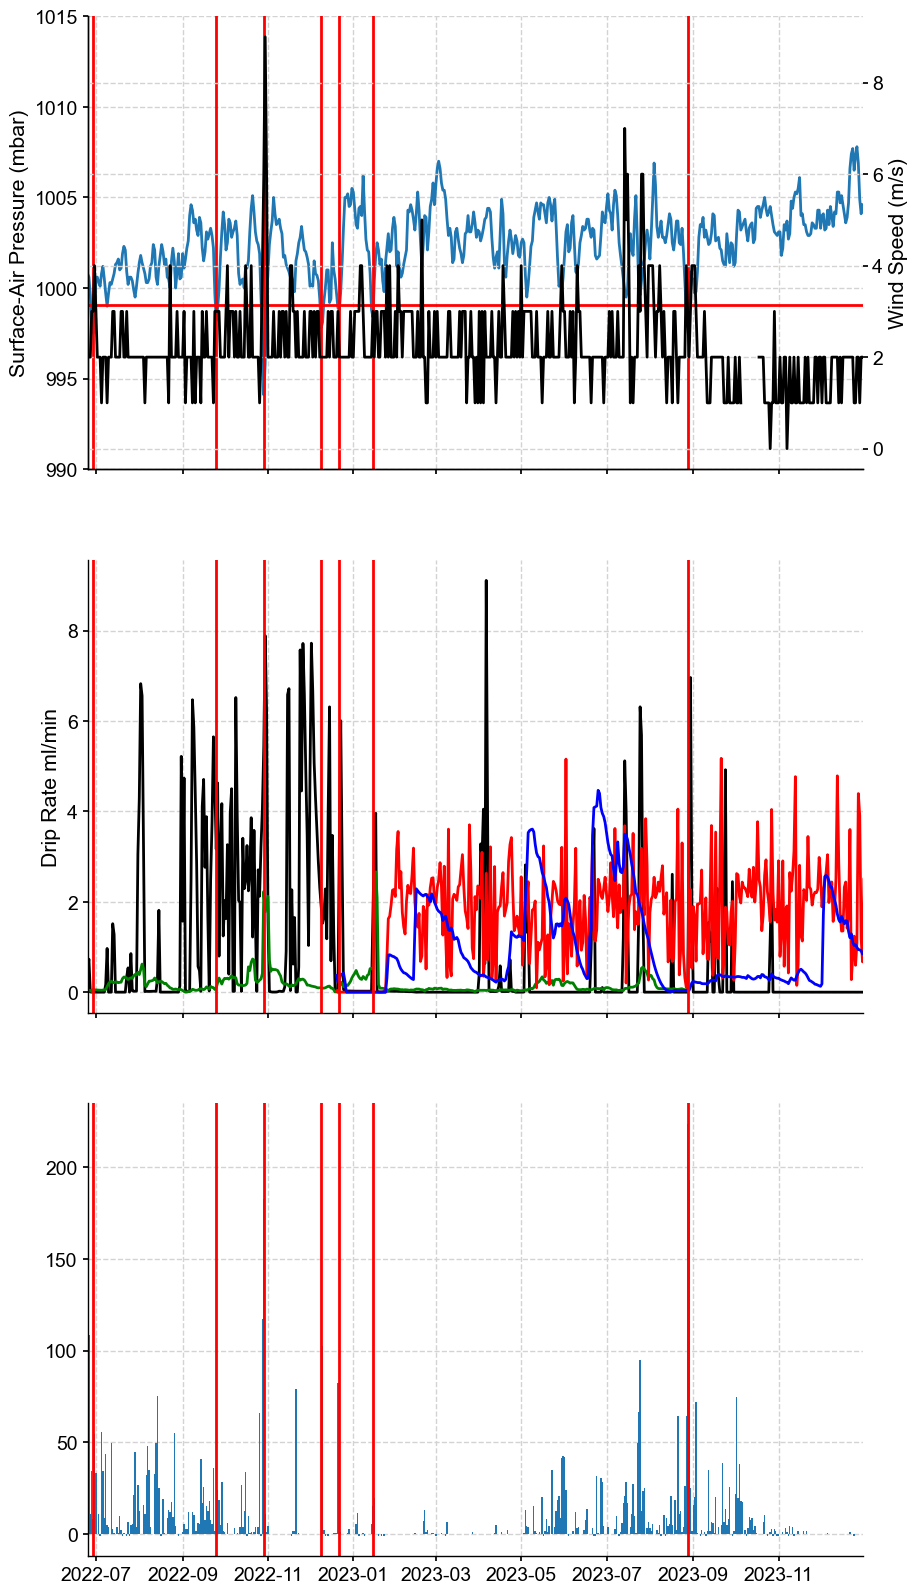

In [16]:
### FIGURE DRIP RATE AND WEATHER STATION DATA FOR PUERTO PRINCESA ###
### with known low pressure events as vertical lines ###
f, (ax1, ax3, ax5) = plt.subplots( 3, 1, figsize = (10,20), sharex = True ) 
ax1.plot( df_coron['Date'], df_coron['PRESSURE'])
ax1.axhline(y=df_coron_LP, color='r', linestyle='-')
ax1.axvline(x= df_coron['Date'][179], color='r', linestyle='-')
ax1.axvline(x= df_coron['Date'][267], color='r', linestyle='-')
ax1.axvline(x= df_coron['Date'][301], color='r', linestyle='-')
ax1.axvline(x= df_coron['Date'][342], color='r', linestyle='-')
ax1.axvline(x= df_coron['Date'][355], color='r', linestyle='-')
ax1.axvline(x= df_coron['Date'][379], color='r', linestyle='-')
ax1.axvline(x= df_coron['Date'][604], color='r', linestyle='-')
ax1.set_ylabel('Surface-Air Pressure (mbar)')
ax1.set_ylim( [990, 1015] )

ax2 = ax1.twinx()
ax2.plot( df_coron['Date'], df_coron['WIND_SPEED'], 'k')
ax2.set_ylabel('Wind Speed (m/s)')
ax3.plot( df_cf_daily['Date'], df_cf_daily['cf_ml/min'], 'k')
ax3.plot( df_stumpy_daily['Date'], df_stumpy_daily['stumpy_ml/min'], 'g')
ax3.plot( df_twins_daily['Date'], df_twins_daily['twins_ml/min'], 'r')
ax3.plot( df_goblin_daily['Date'], df_goblin_daily['goblin_ml/min'], 'b')
ax3.axvline(x= df_coron['Date'][179], color='r', linestyle='-')
ax3.axvline(x= df_coron['Date'][267], color='r', linestyle='-')
ax3.axvline(x= df_coron['Date'][301], color='r', linestyle='-')
ax3.axvline(x= df_coron['Date'][342], color='r', linestyle='-')
ax3.axvline(x= df_coron['Date'][355], color='r', linestyle='-')
ax3.axvline(x= df_coron['Date'][379], color='r', linestyle='-')
ax3.axvline(x= df_coron['Date'][604], color='r', linestyle='-')
ax3.set_ylabel('Drip Rate ml/min')

ax5.bar( df_coron['Date'], df_coron['RAINFALL'], width = 1)
ax5.axvline(x= df_coron['Date'][179], color='r', linestyle='-')
ax5.axvline(x= df_coron['Date'][267], color='r', linestyle='-')
ax5.axvline(x= df_coron['Date'][301], color='r', linestyle='-')
ax5.axvline(x= df_coron['Date'][342], color='r', linestyle='-')
ax5.axvline(x= df_coron['Date'][355], color='r', linestyle='-')
ax5.axvline(x= df_coron['Date'][379], color='r', linestyle='-')
ax5.axvline(x= df_coron['Date'][604], color='r', linestyle='-')
ax5.set_xlim( [ df_coron['Date'][175], df_coron['Date'][729] ] )
#plt.savefig(os.path.join(save_path, 'Puerto.eps'))

(19334.0, 19353.0)

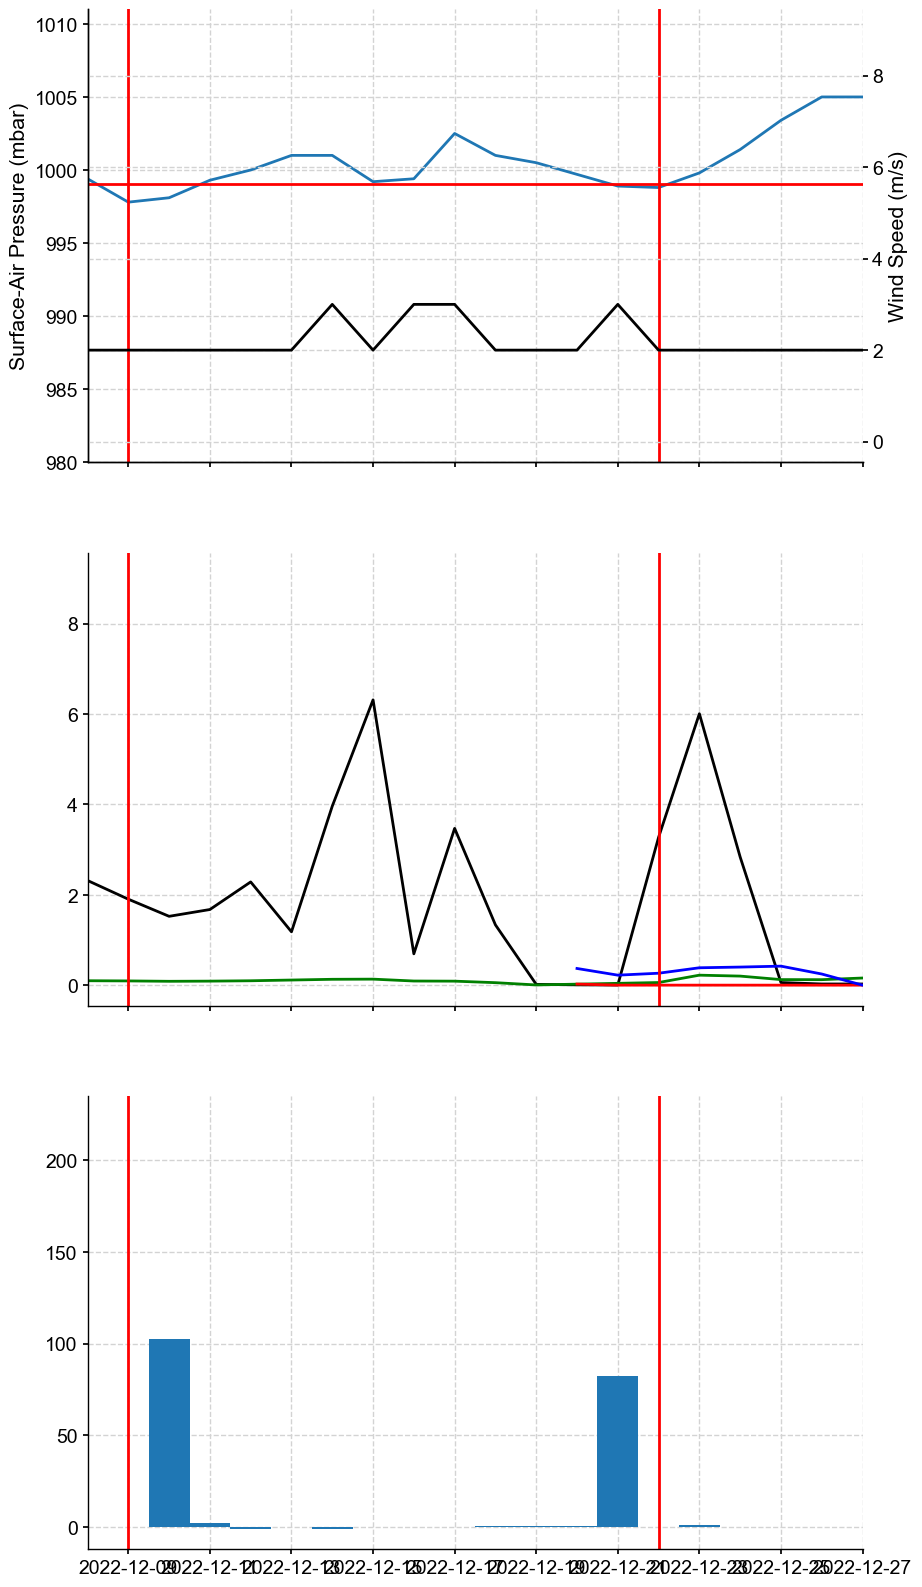

In [18]:
##### ZOOM IN PLOT FOR PALAWAN OCTOBER-DECEMBER 2022 and JUNE-AUGUST 2023 ############

# OCTOBER 25 2022 till DECEMBER 25 2022 #
f, (ax1, ax3, ax5) = plt.subplots( 3, 1, figsize = (10,20), sharex = True ) 
ax1.plot( df_coron['Date'], df_coron['PRESSURE'])
ax1.axhline(y=df_coron_LP, color='r', linestyle='-')
ax1.axvline(x= df_coron['Date'][301], color='r', linestyle='-')
ax1.axvline(x= df_coron['Date'][342], color='r', linestyle='-')
ax1.axvline(x= df_coron['Date'][355], color='r', linestyle='-')
ax1.set_ylabel('Surface-Air Pressure (mbar)')
ax1.set_ylim( [980, 1011] )
ax1.set_xlim( [ df_coron['Date'][341], df_coron['Date'][360] ] )

ax2 = ax1.twinx()
ax2.plot( df_coron['Date'], df_coron['WIND_SPEED'], 'k')
ax2.set_ylabel('Wind Speed (m/s)')
ax3.plot( df_cf_daily['Date'], df_cf_daily['cf_ml/min'], 'k')
ax3.plot( df_stumpy_daily['Date'], df_stumpy_daily['stumpy_ml/min'], 'g')
ax3.plot( df_twins_daily['Date'], df_twins_daily['twins_ml/min'], 'r')
ax3.plot( df_goblin_daily['Date'], df_goblin_daily['goblin_ml/min'], 'b')
ax3.axvline(x= df_coron['Date'][301], color='r', linestyle='-')
ax3.axvline(x= df_coron['Date'][342], color='r', linestyle='-')
ax3.axvline(x= df_coron['Date'][355], color='r', linestyle='-')

ax5.bar( df_coron['Date'], df_coron['RAINFALL'], width = 1)
ax5.axvline(x= df_coron['Date'][301], color='r', linestyle='-')
ax5.axvline(x= df_coron['Date'][342], color='r', linestyle='-')
ax5.axvline(x= df_coron['Date'][355], color='r', linestyle='-')
ax5.set_xlim( [ df_coron['Date'][341], df_coron['Date'][360] ] )
#plt.savefig(os.path.join(save_path, 'PALAWAN_ZOOMIN_2023.eps'))

In [19]:
# COEFICIENT OF VARIATION CALCULATION for drip rate data# 
cv_cf =  np.std( df_cf_daily['cf_ml/min'], ddof=1 ) / np.mean( df_cf_daily['cf_ml/min'] )
cv_st =  np.std( df_stumpy_daily['stumpy_ml/min'], ddof=1 ) / np.mean( df_stumpy_daily['stumpy_ml/min'] )
cv_go =  np.std( df_goblin_daily['goblin_ml/min'], ddof=1 ) / np.mean( df_goblin_daily['goblin_ml/min'] )
cv_tw =  np.std( df_twins_daily['twins_ml/min'], ddof=1 ) / np.mean ( df_twins_daily['twins_ml/min'] )
cv_sl =  np.std( df_slow_daily['slow_ml/min'], ddof=1 ) / np.mean ( df_slow_daily['slow_ml/min'] )
cv_fa =  np.std( df_fast_daily['fast_ml/min'], ddof=1 ) / np.mean ( df_fast_daily['fast_ml/min'] )

display ( cv_cf, cv_st, cv_go, cv_tw, cv_sl, cv_fa )

2.089858780716623

1.4753562077802045

1.0115004513469399

0.5938591607778942

5.401213195382079

0.9666898020505829

In [128]:
# COEFICIENT OF VARIATION CALCULATION WITH REPLACING 0s with NANs#
cv_cf_na =  np.std( df_cf_daily['cf_ml/min'].replace(0, np.nan) , ddof=1 ) / np.mean( df_cf_daily['cf_ml/min'].replace(0, np.nan)  )
cv_st_na =  np.std( df_stumpy_daily['stumpy_ml/min'].replace(0, np.nan) , ddof=1 ) / np.mean( df_stumpy_daily['stumpy_ml/min'].replace(0, np.nan) )
cv_go_na =  np.std( df_goblin_daily['goblin_ml/min'].replace(0, np.nan), ddof=1 ) / np.mean( df_goblin_daily['goblin_ml/min'].replace(0, np.nan) )
cv_tw_na =  np.std( df_twins_daily['twins_ml/min'].replace(0, np.nan), ddof=1 ) / np.mean ( df_twins_daily['twins_ml/min'].replace(0, np.nan) )
cv_sl_na =  np.std( df_slow_daily['slow_ml/min'].replace(0, np.nan), ddof=1 ) / np.mean ( df_slow_daily['slow_ml/min'].replace(0, np.nan) )
cv_fa_na =  np.std( df_fast_daily['fast_ml/min'].replace(0, np.nan), ddof=1 ) / np.mean ( df_fast_daily['fast_ml/min'].replace(0, np.nan) )

display ( cv_cf_na, cv_st_na, cv_go_na, cv_tw_na, cv_sl_na, cv_fa_na )

1.449260429854058

1.4753562077802045

0.9469321623461079

0.5144204863022026

1.0761451324644953

0.8736117643746277

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_ol

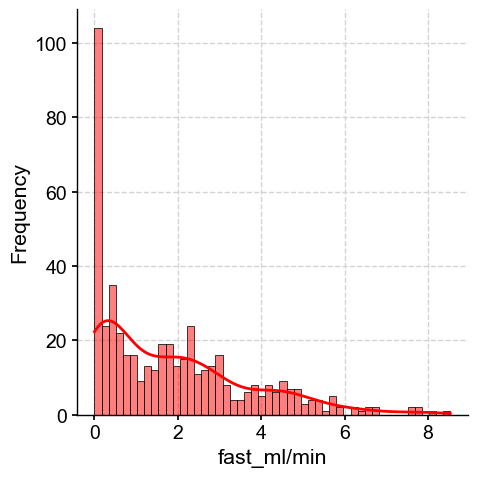

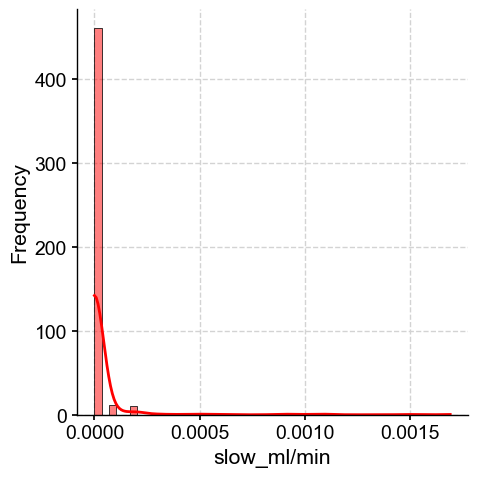

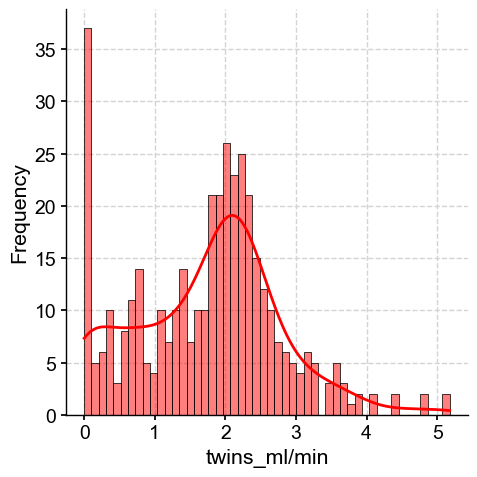

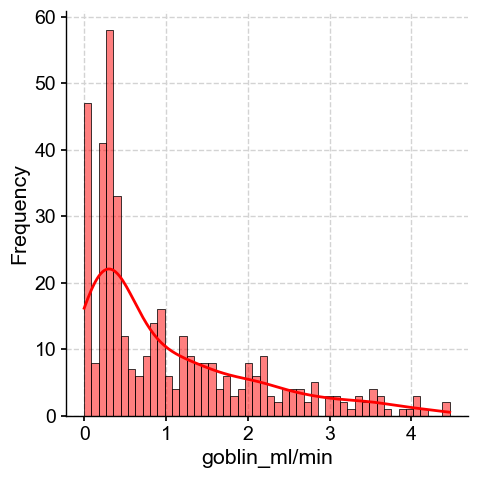

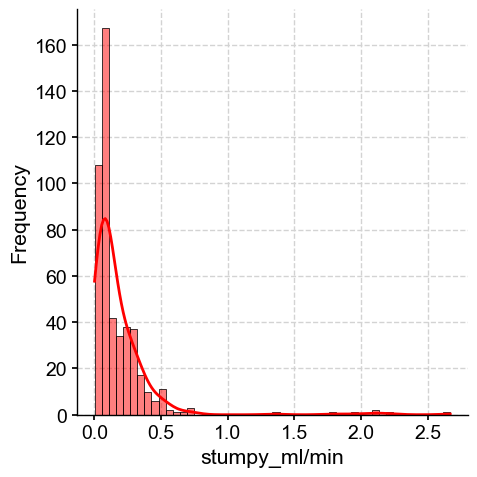

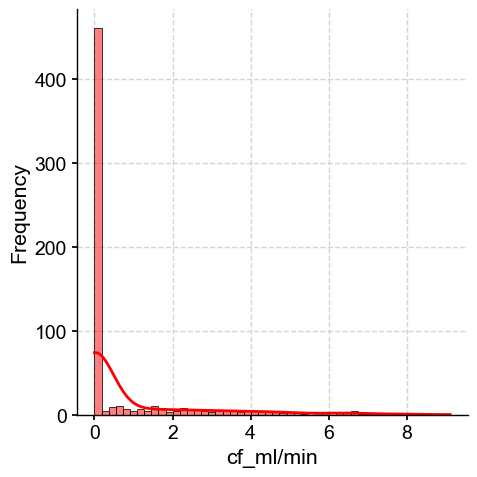

In [20]:
# PDFs of DRIP RATES # 
ax = sns.displot(df_fast_daily['fast_ml/min'],
                  bins=50,
                  kde=True,
                  color='red')
ax.set(xlabel='fast_ml/min', ylabel='Frequency')
#plt.savefig(os.path.join(save_path, 'pdf_fast.eps'))

ax = sns.displot(df_slow_daily['slow_ml/min'],
                  bins=50,
                  kde=True,
                  color='red')
ax.set(xlabel='slow_ml/min', ylabel='Frequency')
#plt.savefig(os.path.join(save_path, 'pdf_slow.eps'))

ax = sns.displot(df_twins_daily['twins_ml/min'],
                  bins=50,
                  kde=True,
                  color='red')
ax.set(xlabel='twins_ml/min', ylabel='Frequency')
#plt.savefig(os.path.join(save_path, 'pdf_twins.eps'))

ax = sns.displot(df_goblin_daily['goblin_ml/min'],
                  bins=50,
                  kde=True,
                  color='red')
ax.set(xlabel='goblin_ml/min', ylabel='Frequency')
#plt.savefig(os.path.join(save_path, 'pdf_goblin.eps'))

ax = sns.displot(df_stumpy_daily['stumpy_ml/min'],
                  bins=50,
                  kde=True,
                  color='red')
ax.set(xlabel='stumpy_ml/min', ylabel='Frequency')
#plt.savefig(os.path.join(save_path, 'pdf_stumpy.eps'))

ax = sns.displot(df_cf_daily['cf_ml/min'],
                  bins=50,
                  kde=True,
                  color='red')
ax.set(xlabel='cf_ml/min', ylabel='Frequency')
#plt.savefig(os.path.join(save_path, 'pdf_cf.eps'))

plt.show()

In [140]:
# FOR KARST SOLUTION 
df_fast_daily["Date_Time"] = pd.to_datetime(df_fast_daily["Date"])
df_fast_daily = df_fast_daily.set_index("Date_Time")

obs_monthly_rate = (
    df_fast_daily["fast_drops/minute"]
    .resample("MS")
    .mean()
)

obs_monthly_interval = 60 / obs_monthly_rate

obs_monthly = pd.DataFrame({
    "drops_per_min": obs_monthly_rate,
    "interval_sec": obs_monthly_interval
})

obs_monthly.to_csv("observed_monthly_drip.csv")



drip_obs = df_fast_daily.set_index("Date")

# Number of observations per month
monthly_n = (
    drip_obs["fast_drops/minute"]
    .resample("MS")
    .count()
)

# First and last observation in each month
monthly_first = (
    drip_obs["fast_drops/minute"]
    .resample("MS")
    .apply(lambda x: x.first_valid_index())
)

monthly_last = (
    drip_obs["fast_drops/minute"]
    .resample("MS")
    .apply(lambda x: x.last_valid_index())
)

coverage = pd.DataFrame({
    "n_obs": monthly_n,
    "first_obs": monthly_first,
    "last_obs": monthly_last
})

print(coverage.loc["2022-08":"2022-12"])

            n_obs  first_obs   last_obs
Date                                   
2022-08-01     21 2022-08-11 2022-08-31
2022-09-01     30 2022-09-01 2022-09-30
2022-10-01     31 2022-10-01 2022-10-31
2022-11-01     30 2022-11-01 2022-11-30
2022-12-01     31 2022-12-01 2022-12-31


In [141]:
# FOR KARST SOLUTION 
aug = drip_obs.loc["2022-08", "fast_drops/minute"]

print("August observations:", aug.count())
print("First observation:", aug.first_valid_index())
print("Last observation:", aug.last_valid_index())

print("\nAugust rate summary:")
print(aug.describe())

print("\nNumber of zero values:", (aug == 0).sum())

August observations: 21
First observation: 2022-08-11 00:00:00
Last observation: 2022-08-31 00:00:00

August rate summary:
count    21.000000
mean      0.186045
std       0.316996
min       0.000000
25%       0.000000
50%       0.001389
75%       0.236806
max       1.015972
Name: fast_drops/minute, dtype: float64

Number of zero values: 7


In [142]:
# FOR KARST SOLUTION 
for month in [
    "2022-08", "2022-09", "2022-10",
    "2022-11", "2022-12"
]:
    x = drip_obs.loc[month, "fast_drops/minute"]

    print(
        month,
        "N =", x.count(),
        "zeros =", (x == 0).sum(),
        "mean =", x.mean(),
        "median =", x.median(),
        "min =", x.min(),
        "max =", x.max()
    )

2022-08 N = 21 zeros = 7 mean = 0.18604497357936509 median = 0.001388889 min = 0.0 max = 1.0159722221666667
2022-09 N = 30 zeros = 1 mean = 9.646273148166665 median = 3.4187500000833335 min = 0.0 max = 56.07569444666667
2022-10 N = 31 zeros = 0 mean = 15.985340501725807 median = 12.131249998333333 min = 8.604166666666666 max = 59.55625
2022-11 N = 30 zeros = 0 mean = 19.037476851833333 median = 18.338888887499998 min = 14.028472223333333 max = 29.666666664999997
2022-12 N = 31 zeros = 0 mean = 13.847683691951614 median = 12.947222223333334 min = 7.640972222333333 max = 20.91388889166667


(19593.0, 19608.0)

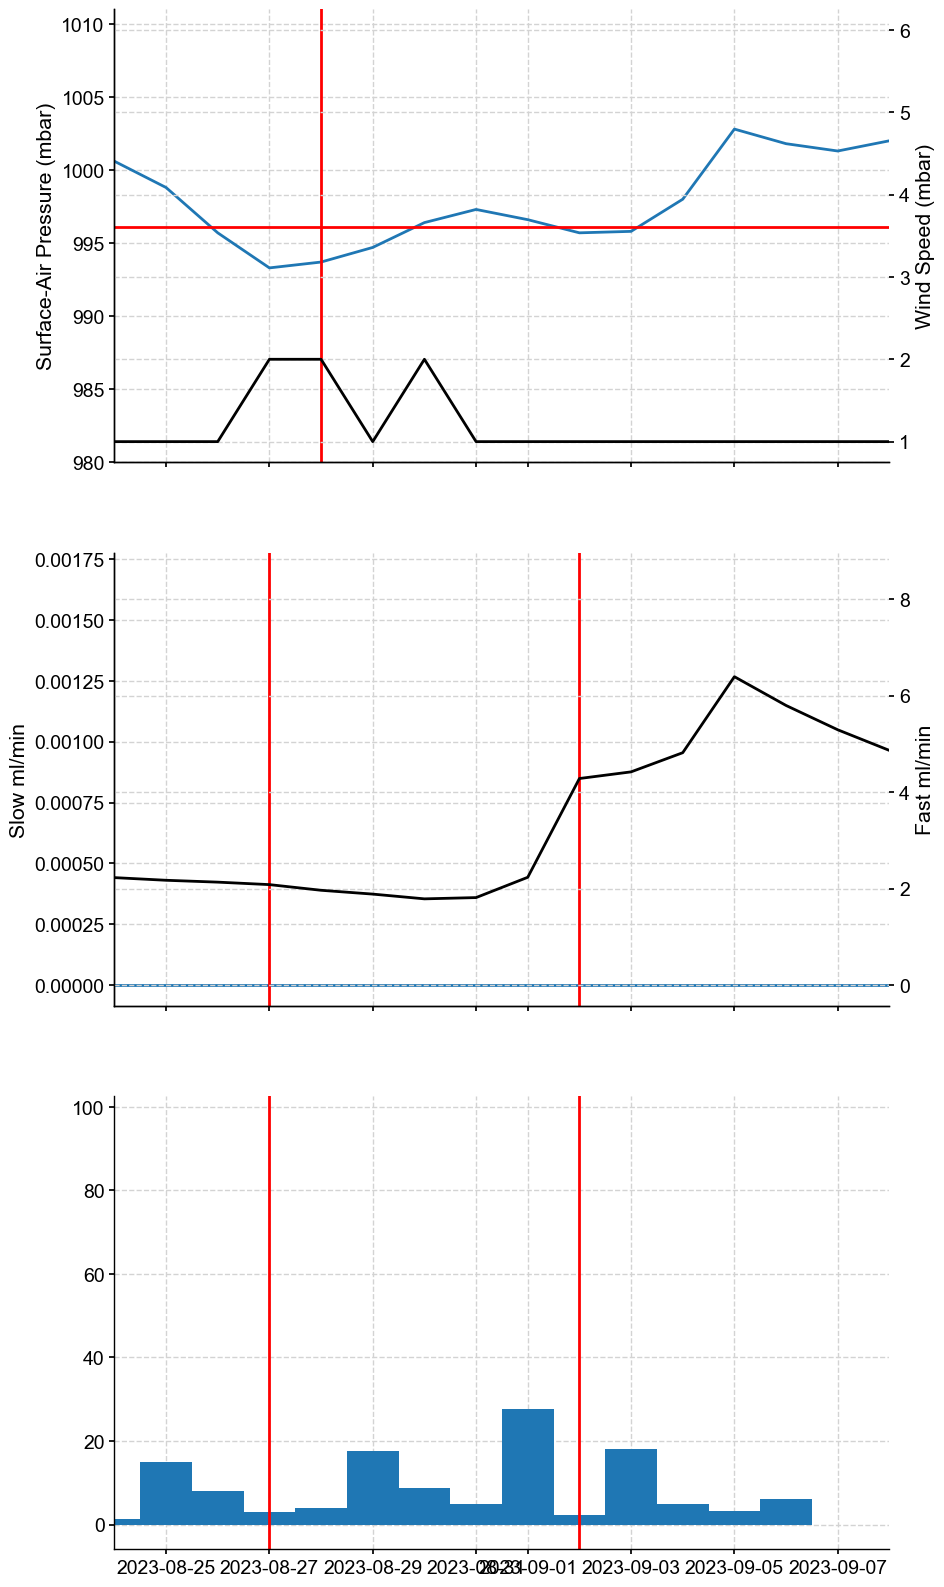

In [23]:
##### ZOOM IN PLOT FOR BNBNP SEPTEMBER-OCTOBER 2022 and JULY-SEPT 2023 ############

# SEP 01 2022 till OCT 31 2022 #
f, (ax1, ax3, ax5) = plt.subplots( 3, 1, figsize = (10,20), sharex = True ) 
ax1.plot( df_clsu['Date'], df_clsu['PRESSURE'])
ax1.axhline(y=df_clsu_LP, color='r', linestyle='-')
ax1.axvline(x= df_clsu['Date'][604], color='r', linestyle='-')
ax1.set_ylabel('Surface-Air Pressure (mbar)')
ax1.set_ylim( [980, 1011] )
ax1.set_xlim( [ df_clsu['Date'][550], df_clsu['Date'][615] ] )

ax2 = ax1.twinx()
ax2.plot( df_clsu['Date'], df_clsu['WIND_SPEED'], 'k')
ax2.set_ylabel('Wind Speed (mbar)')
ax3.plot( df_slow_daily['Date'], df_slow_daily['slow_ml/min'])
ax3.axvline(x= df_clsu['Date'][559], color='r', linestyle='-')
ax3.axvline(x= df_clsu['Date'][570], color='r', linestyle='-')
ax3.axvline(x= df_clsu['Date'][603], color='r', linestyle='-')
ax3.axvline(x= df_clsu['Date'][609], color='r', linestyle='-')
ax3.set_ylabel('Slow ml/min')

ax4 = ax3.twinx()
ax4.plot( df_fast_daily['Date'], df_fast_daily['fast_ml/min'], 'k')
ax4.set_ylabel('Fast ml/min')
ax5.bar( df_clsu['Date'], df_clsu['RAINFALL'], width = 1)
ax5.axvline(x= df_clsu['Date'][559], color='r', linestyle='-')
ax5.axvline(x= df_clsu['Date'][570], color='r', linestyle='-')
ax5.axvline(x= df_clsu['Date'][603], color='r', linestyle='-')
ax5.axvline(x= df_clsu['Date'][609], color='r', linestyle='-')
ax5.set_xlim( [ df_clsu['Date'][600], df_clsu['Date'][615] ] )
#plt.savefig(os.path.join(save_path, 'BNBNP_ZOOMIN_2023.eps'))

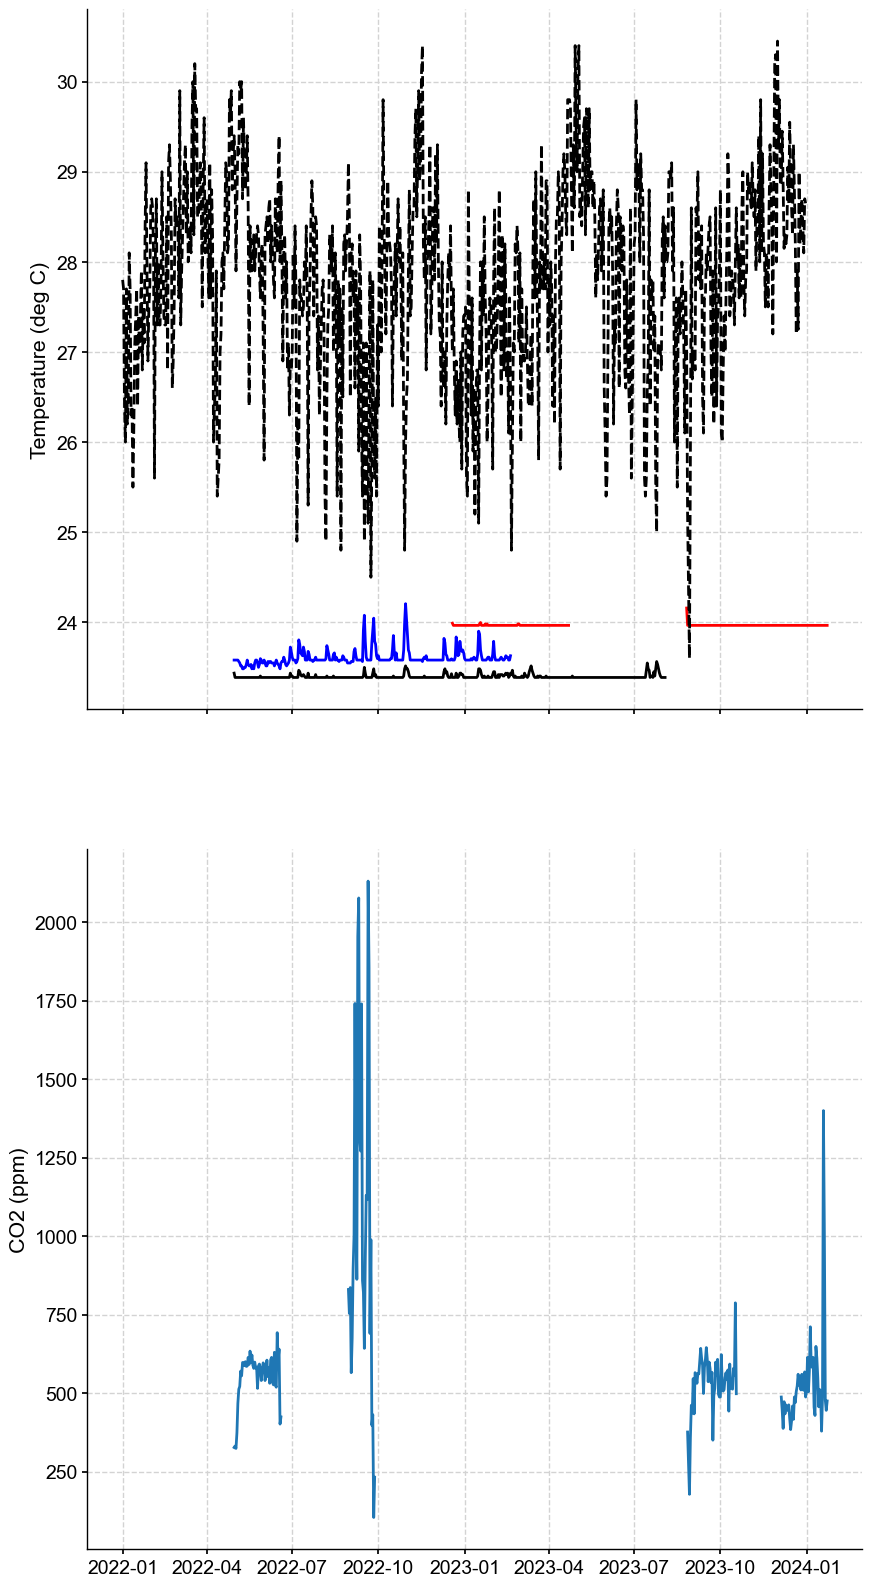

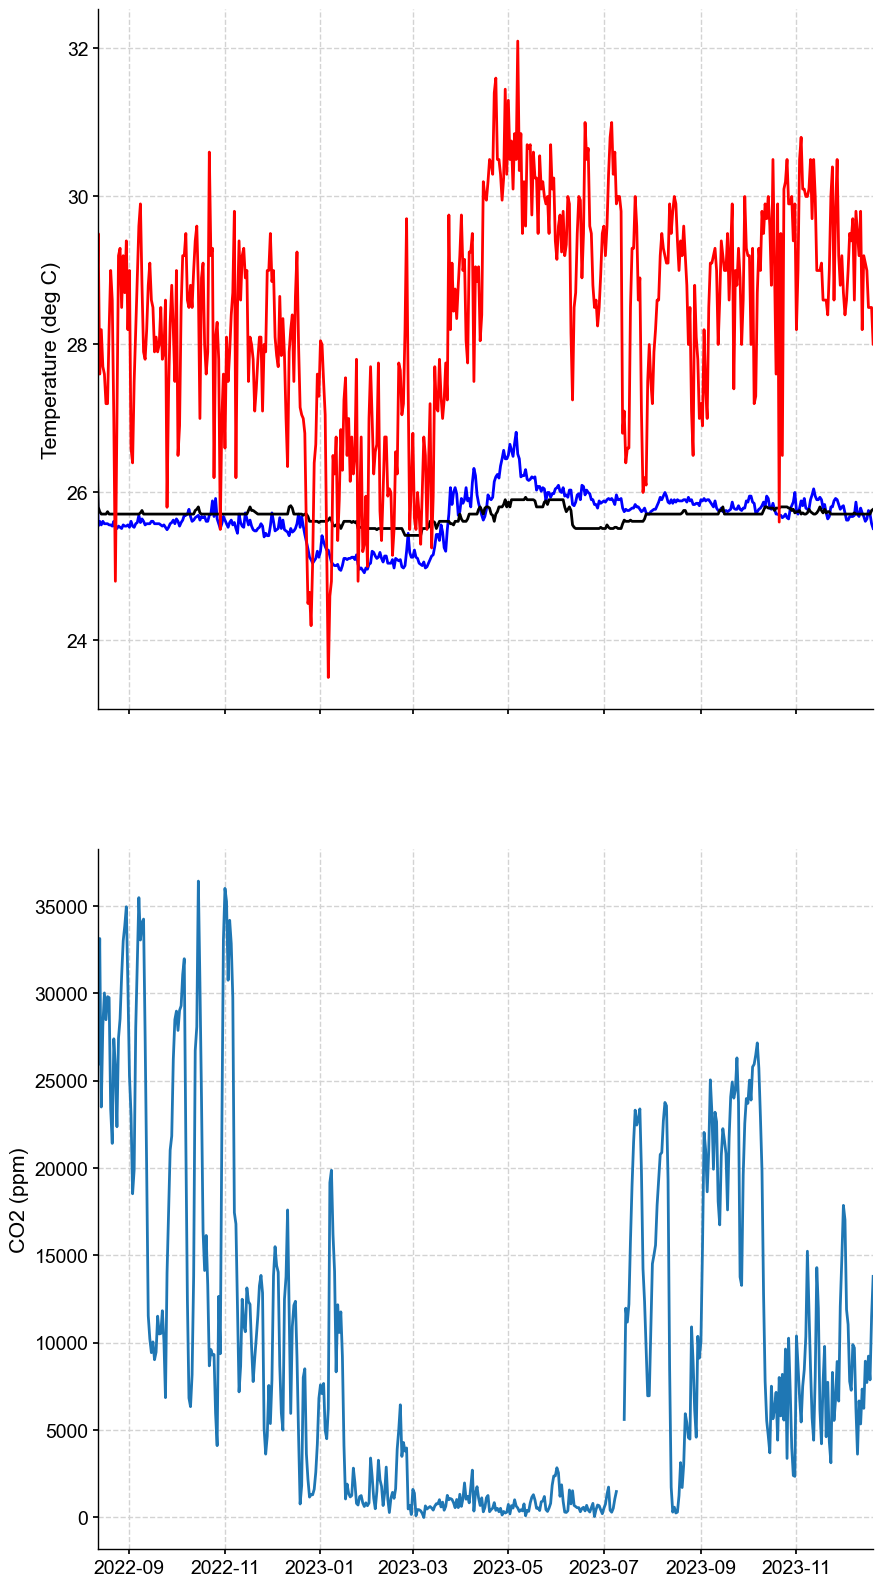

In [24]:
##### PLOT TEMP and CO2 for PALAWAN #####
f, (ax1, ax2) = plt.subplots( 2, 1, figsize = (10,20), sharex = True ) 
ax1.plot( df_chocf_daily['Date'], df_chocf_daily['CF_Temp'],'b')
ax1.plot( df_st_daily['Date'], df_st_daily['Stumpy_Temp'],'k')
ax1.plot( df_gob_daily['Date'], df_gob_daily['Goblin_Temp'],'r')
ax1.plot()
ax1.plot( df_coron['Date'], df_coron['TMEAN'],'k--')
ax1.set_ylabel('Temperature (deg C)')
ax2.plot( df_pal_co2_daily['Date'], df_pal_co2_daily['ppm'])
ax2.set_ylabel('CO2 (ppm)')
plt.savefig(os.path.join(save_path, 'temp_CO2_palawan.eps'))
plt.show()
### CO2 and temperature for Biak Na Bato #####
f, (ax1, ax2) = plt.subplots( 2, 1, figsize = (10,20), sharex = True ) 
ax1.plot( df_entra_daily['Date'], df_entra_daily['Entrance_Temp'],'b')
ax1.plot( df_inte_daily['Date'], df_inte_daily['Interior_Temp'],'k')
ax1.plot( df_clsu['Date'], df_clsu['TMEAN'],'r')
ax1.set_ylabel('Temperature (deg C)')
ax1.set_xlim( [ df_clsu['Date'][223], df_clsu['Date'][718] ] )
ax2.plot( df_bnb_co2_daily['Date'], df_bnb_co2_daily['CO2'])
ax2.set_ylabel('CO2 (ppm)')
#plt.savefig(os.path.join(save_path, 'temp_cCO.eps'))
plt.show()

In [25]:
#### CLIMATOLOGY MAPS USING ERA
data = xr.open_dataset('/Users/natashasekhon/Downloads/ERA5.nc')

lat = data.latitude
lon = data.longitude
tp  = data.tp
### LONGITUDE FOR PHILIPPINES
tp_phili = tp[:,0:61,420:481]
wind_u = data.u10
wind_u_phili = wind_u[:,0:61,420:481]
wind_v = data.v10
wind_v_phili = wind_v[:,0:61,420:481]


FileNotFoundError: [Errno 2] No such file or directory: '/Users/natashasekhon/Downloads/ERA5.nc'

In [ ]:
#### CLIMATOLOGY MAPS USING ERA
uset_by_season = wind_u.groupby('time.season').mean('time')
u_range = ( ( uset_by_season.sel(season='MAM') ) )

vset_by_season = wind_v.groupby('time.season').mean('time')
v_range = ( ( vset_by_season.sel(season='MAM') ) )

WS = np.sqrt(wind_u**2 + wind_v**2)

dset_by_season = tp_phili.groupby('time.season').sum('time')
tmp_range = ( ( ( dset_by_season.sel(season='MAM') ) ) * 1000 )/3# m to mm
tmp_range.max()

/var/folders/cm/syqd5kfn0xl_t2hqr3m3szhc0000gn/T/ipykernel_98453/258172721.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  orig_map=plt.cm.get_cmap('terrain')


NameError: name 'lon' is not defined

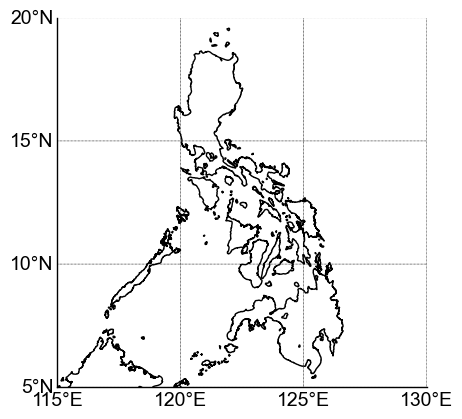

In [17]:
#### CLIMATOLOGY MAPS USING ERA
m = Basemap(projection='cyl', llcrnrlon=115, llcrnrlat=5, urcrnrlon=130, urcrnrlat=20, resolution='h')
m.drawcoastlines(1)
m.drawcountries(1)

### Latitude ###
parallels = np.arange(-20,20+0.15,5)
m.drawparallels(parallels, labels=[1,0,0,0], linewidth=0.5)
### Longitude ###
meridians = np.arange(115,130+0.25,5)
m.drawmeridians(meridians, labels=[0,0,0,1], linewidth=0.5)

#### Countour ####
orig_map=plt.cm.get_cmap('terrain') 
  
# reversing the original colormap using reversed() function 
reversed_map = orig_map.reversed() 
levels = np.linspace(0,650,50)
#cf = plt.contourf(lon,lat,tmp_range, levels = levels, cmap=reversed_map) ### going from m/day to mm/day
cf = plt.contourf(lon[420:481],lat[0:61],tmp_range, levels = levels, cmap=reversed_map ) ### going from m/day to mm/day
Q = plt.quiver(lon[::6],lat[::6],wind_u[3,::6,::6],wind_v[3,::6,::6], scale_units='xy', scale=5, width=0.0025)
# 1 for F; 3 for april; 6 for July; 8 for October

#Q = plt.quiver(lon[::6],lat[::6],wind_u[5,::6,::6],wind_v[5,::6,::6], scale_units='xy', scale=3, width=0.0025)
qk = plt.quiverkey(Q, 1, 1.04, 5,str(5)+' m/s',labelpos='E',coordinates='axes')
cb = plt.colorbar(cf, fraction=0.255, pad=0.04, ticks=range(0, 650, 50) )
cb.set_label('mm',  fontsize=15)
#plt.savefig(os.path.join(save_path, 'MAM_V2.eps'))
plt.show()

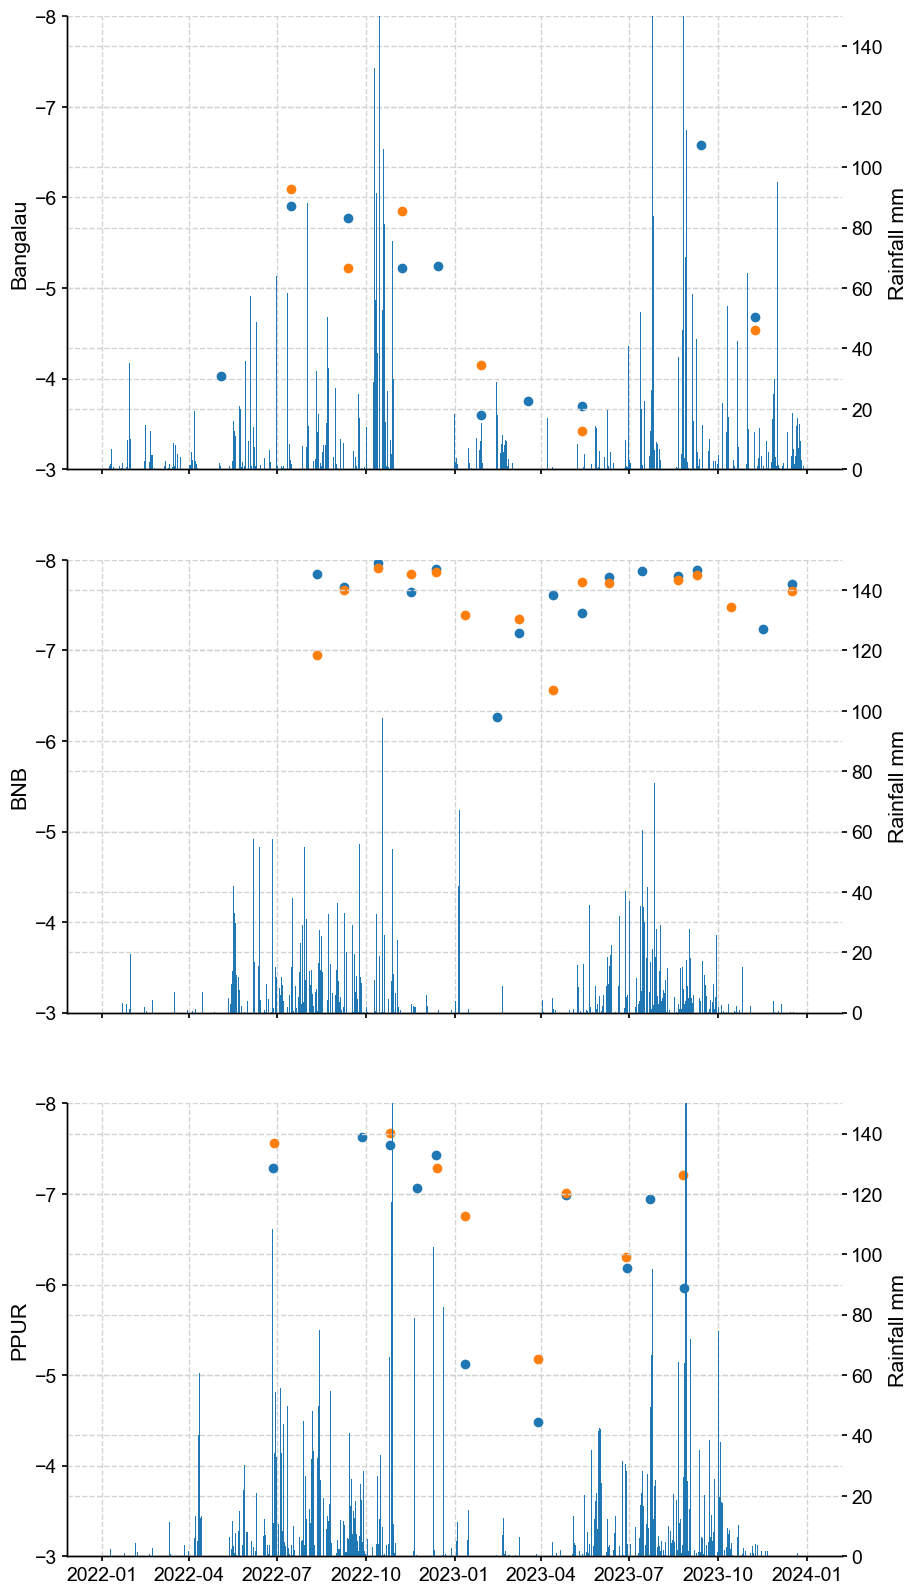

(0.0, 16.0)

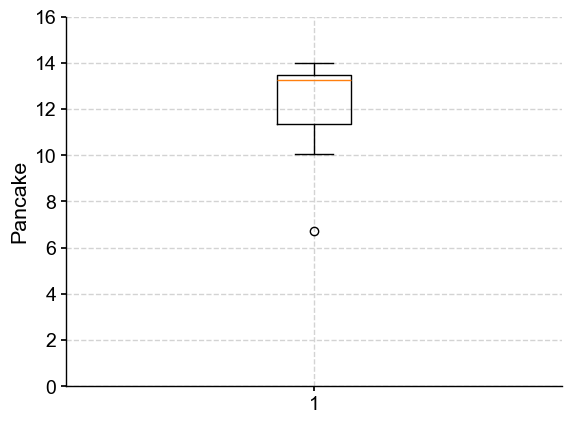

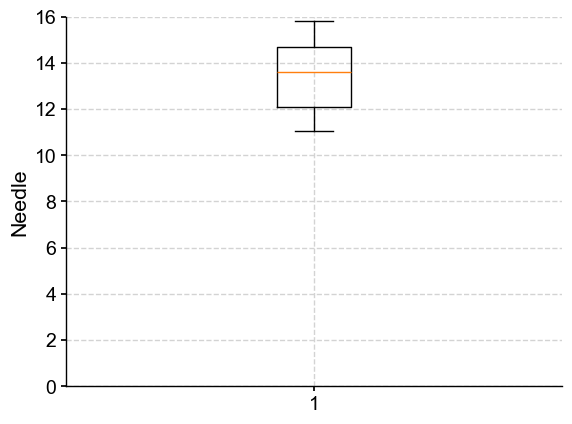

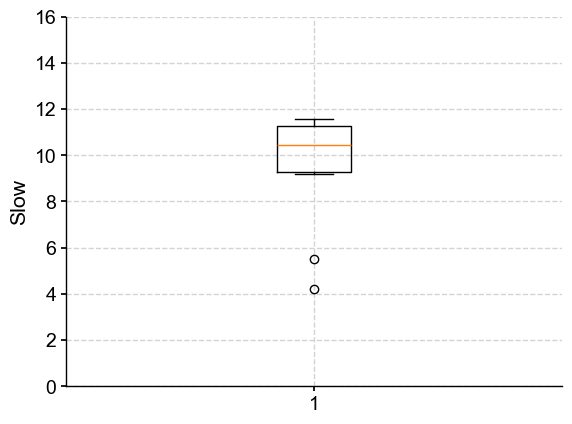

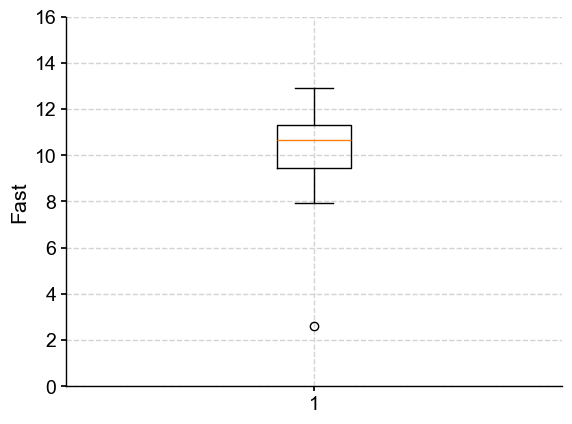

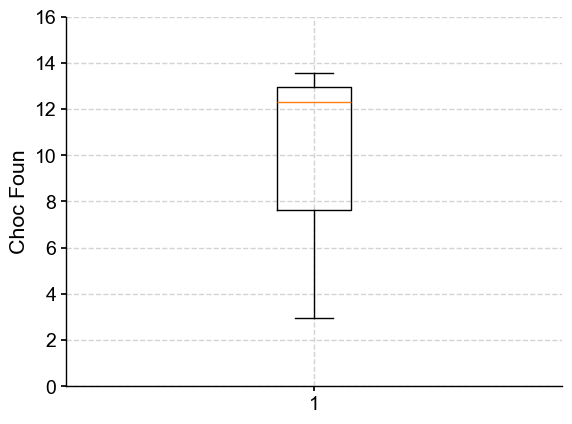

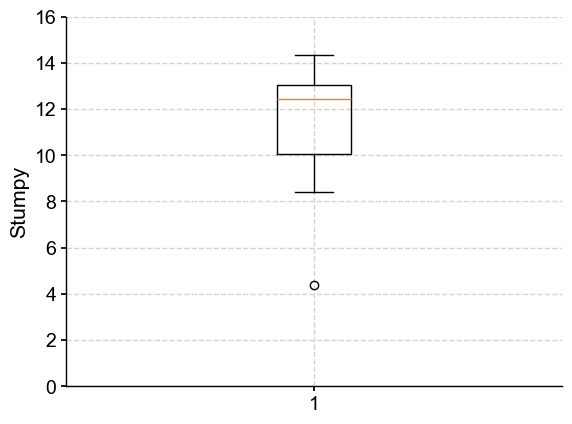

In [14]:
#### FIGURE DRIP WATER TIME SERIES #######
water_stable_path = 'Data/Chemical/stable_iso/water_stable.xlsx'

#### ISOTOPE DATA ######
ppur_iso  = pd.read_excel(wateyr_stable_path, sheet_name='PPUR_IAEA')
banga_iso = pd.read_excel(water_stable_path, sheet_name='Bangalau_IAEA')
bnb_iso   = pd.read_excel(water_stable_path, sheet_name='BNB_IAEA')

#### PIVOT DATA ######
def drip_pivot(cave, parameter):
    iso_stable = pd.pivot_table(cave.reset_index(),index='Date', columns='Site Name', values=parameter)
    return iso_stable

bnb_o18 = drip_pivot(bnb_iso, 'd18o')
bnb_h   = drip_pivot(bnb_iso, 'dH')
bnb_de  = drip_pivot(bnb_iso, 'dexcess')

ppur_o18 = drip_pivot(ppur_iso, 'd18o')
ppur_h   = drip_pivot(ppur_iso, 'dH')
ppur_de  = drip_pivot(ppur_iso, 'dexcess')

banga_o18 = drip_pivot(banga_iso, 'd18o')
banga_h   = drip_pivot(banga_iso, 'dH')
banga_de  = drip_pivot(banga_iso, 'dexcess')


#### FIGURE XXXXX ##########
f, (ax1, ax3, ax5) = plt.subplots( 3, 1, figsize = (10,20), sharex = True ) 
ax1.scatter(banga_o18.index,banga_o18['Pancake'].values)
ax1.scatter(banga_o18.index,banga_o18['Needle'].values)
ax1.set_ylim(-8, -3)
ax1.invert_yaxis()
ax1.set_ylabel('Bangalau')
ax2 = ax1.twinx()
ax2.bar( df_aparri['Date'], df_aparri['RAINFALL'], width = 1)
ax2.set_ylabel('Rainfall mm')
ax2.set_ylim(0,150)
ax3.scatter(bnb_o18.index,bnb_o18['Fast'].values)
ax3.scatter(bnb_o18.index,bnb_o18['Slow'].values)
ax3.set_ylabel('BNB')
ax3.set_ylim(-8,-3)
ax3.invert_yaxis()
ax4 = ax3.twinx()
ax4.bar( df_clsu['Date'], df_clsu['RAINFALL'], width = 1)
ax4.set_ylabel('Rainfall mm')
ax4.set_ylim(0,150)
ax5.scatter(ppur_o18.index,ppur_o18['Chocolate Fountain'].values)
ax5.scatter(ppur_o18.index,ppur_o18['Stumpy'].values)
ax5.set_ylabel('PPUR')
ax5.set_ylim(-8,-3)
ax5.invert_yaxis()
ax6 = ax5.twinx()
ax6.bar( df_coron['Date'], df_coron['RAINFALL'], width = 1) 
ax6.set_ylabel('Rainfall mm')
ax6.set_ylim(0,150)
plt.savefig(os.path.join(save_path, 'rain_d18o.eps')) #this is now updated to Coron instead of Puerto
plt.show()

### BOX PLOT ######
fig, ax = plt.subplots()
ax.boxplot(banga_de['Pancake'].values[~np.isnan(banga_de['Pancake'].values)])
ax.invert_yaxis()
ax.set_ylabel('Pancake')
ax.set_ylim(0, 16)
#plt.savefig(os.path.join(save_path, 'pancake_box_de.eps'))

fig, ax = plt.subplots()
ax.boxplot(banga_de['Needle'].values[~np.isnan(banga_de['Needle'].values)])
ax.invert_yaxis()
ax.set_ylabel('Needle')
ax.set_ylim(0, 16)
#plt.savefig(os.path.join(save_path, 'needle_box_de.eps'))

fig, ax = plt.subplots()
ax.boxplot(bnb_de['Slow'].values[~np.isnan(bnb_de['Slow'].values)])
ax.invert_yaxis()
ax.set_ylabel('Slow')
ax.set_ylim(0, 16)
#plt.savefig(os.path.join(save_path, 'slow_box_de.eps'))

fig, ax = plt.subplots()
ax.boxplot(bnb_de['Fast'].values[~np.isnan(bnb_de['Fast'].values)])
ax.invert_yaxis()
ax.set_ylabel('Fast')
ax.set_ylim(0, 16)
#plt.savefig(os.path.join(save_path, 'fast_box_de.eps'))

fig, ax = plt.subplots()
ax.boxplot(ppur_de['Chocolate Fountain'].values[~np.isnan(ppur_de['Chocolate Fountain'].values)])
ax.invert_yaxis()
ax.set_ylabel('Choc Foun')
ax.set_ylim(0, 16)
#plt.savefig(os.path.join(save_path, 'choc_box_de.eps'))

fig, ax = plt.subplots()
ax.boxplot(ppur_de['Stumpy'].values[~np.isnan(ppur_de['Stumpy'].values)])
ax.invert_yaxis()
ax.set_ylabel('Stumpy')
ax.set_ylim(0, 16)
#plt.savefig(os.path.join(save_path, 'stumpy_box_de.eps'))

In [23]:
# geting statiscs on drip water values
import statistics
print (banga_o18['Needle'].values)

statistics.median(banga_o18['Needle'].values)


[        nan -6.094      -5.217      -5.84765738         nan -4.15266667
         nan -3.42533333         nan -4.53808333]


nan

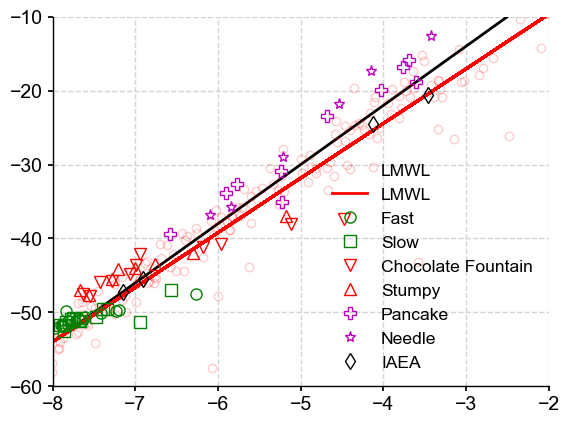

In [27]:
# IAEA GNIP
gmwl_iso  = pd.read_excel(water_stable_path, sheet_name='gmwl')
lmwl_iso  = pd.read_excel(water_stable_path, sheet_name='lmwl')

### Calculate the line of best fit
finiteIdx = np.isfinite( lmwl_iso['o18_gnip_manila'] ) & np.isfinite( lmwl_iso['d_gnip_manila'] )
slope, intercept = np.polyfit(lmwl_iso['o18_gnip_manila'][finiteIdx], lmwl_iso['d_gnip_manila'][finiteIdx], 1)
line = slope * lmwl_iso['o18_gnip_manila'][finiteIdx] + intercept

plt.plot(gmwl_iso['O'], gmwl_iso['D'], color = 'black')
plt.plot(lmwl_iso['o18_gnip_manila'], lmwl_iso['d_gnip_manila'],'ro', markerfacecolor = 'none', markersize = 6, alpha = 0.2, label = 'LMWL' )
plt.plot(lmwl_iso['o18_gnip_manila'][finiteIdx], line, color='red', label='LMWL')

plt.plot(bnb_o18['Fast'].values,bnb_h['Fast'].values, 'go', markerfacecolor = 'none', markersize = 8, label = 'Fast')
plt.plot(bnb_o18['Slow'].values,bnb_h['Slow'].values, 'gs', markerfacecolor = 'none', markersize = 8, label = 'Slow')

plt.plot(ppur_o18['Chocolate Fountain'].values,ppur_h['Chocolate Fountain'].values, 'rv', markerfacecolor = 'none', markersize = 8, label = 'Chocolate Fountain')
plt.plot(ppur_o18['Stumpy'].values,ppur_h['Stumpy'].values, 'r^', markerfacecolor = 'none', markersize = 8, label = 'Stumpy')

plt.plot(banga_o18['Pancake'].values,banga_h['Pancake'].values, 'mP', markerfacecolor = 'none', markersize = 8, label = 'Pancake')
plt.plot(banga_o18['Needle'].values, banga_h['Needle'].values, 'm*', markerfacecolor = 'none', markersize = 8, label = 'Needle')

plt.plot([-3.465833333,-4.126759259,-7.147037037,-6.907407407],[-20.65,-24.54907407,-47.27333333,-45.49953704],'kd',markerfacecolor = 'none', markersize = 8, label = 'IAEA' )
plt.ylim(-60, -10)
plt.xlim(-8, -2)
plt.legend()

#plt.savefig(os.path.join(save_path, 'IAEA_V2.eps'))
plt.show()

NaNs have been detected and dropped.
Time axis values sorted in ascending order


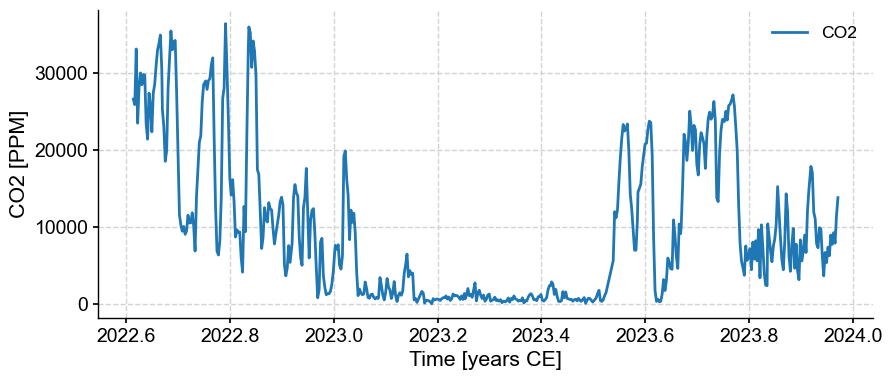

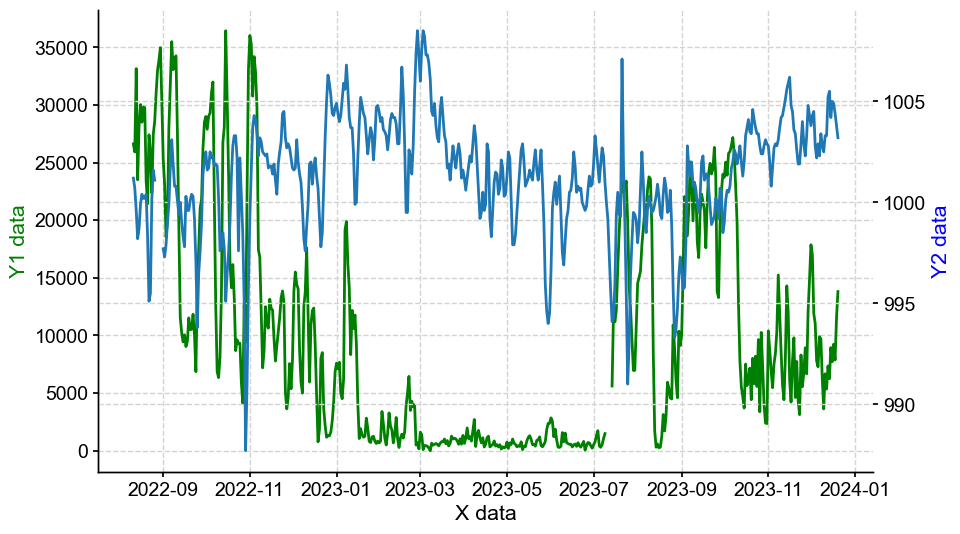

In [83]:
######## CO2 data daily for WAVELET ANALYSIS #########
bulacan_CO2 = df_bnb_co2_daily
bulacan_CO2['CO2'] = df_bnb_co2_daily['CO2']
bulacan_CO2['NDate'] = df_bnb_co2_daily['Date'].map( lambda  x: x.year + ( (x.month-1)/12) + x.day/365  )
ts_bul_co2 = pyleo.Series(time=bulacan_CO2['NDate'], value=bulacan_CO2['CO2'],
                  time_name='Years', value_name='CO2',
                  time_unit='CE', value_unit='PPM',
                  label='CO2', clean_ts=True)
### Changing CO2 data into the format that PYLEO CLIM WANTS ###

# ------  PLOTTING DATA QUICKLY TO SEE WHAT IT LOOKS LIKE ---- #
fig, ax      = ts_bul_co2.plot()
fig, ax1 = plt.subplots(figsize=(10,6))
ax2 = ax1.twinx()
ax1.plot( bulacan_CO2['Date'], bulacan_CO2['CO2'],'g' )
ax2.plot( df_clsu['Date'][222:719], df_clsu['PRESSURE'][222:719] )
ax1.set_xlabel('X data')
ax1.set_ylabel('Y1 data', color='g')
ax2.set_ylabel('Y2 data', color='b')
plt.savefig(os.path.join(save_path, 'Bulacan_CO2.eps'))

NaNs have been detected and dropped.
Time axis values sorted in ascending order


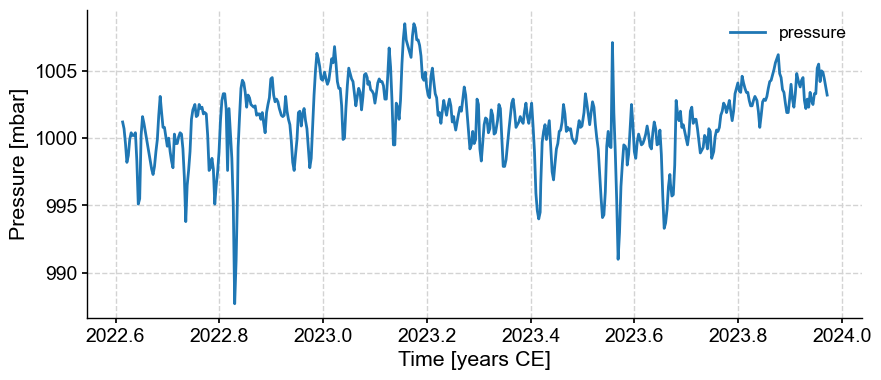

In [84]:
###### CO2 data daily for WAVELET ANALYSIS #######
pressure_CO2 = df_clsu[222:719]
pressure_CO2['Pressure'] = df_clsu['PRESSURE'][222:719]
pressure_CO2['NDate'] = df_clsu['Date'][222:719].map(lambda  x: x.year + ( (x.month-1)/12) + x.day/365  )
ts_bul_pres = pyleo.Series(time=pressure_CO2['NDate'], value=pressure_CO2['Pressure'],
                  time_name='Years', value_name='Pressure',
                  time_unit='CE', value_unit='mbar',
                  label='pressure', clean_ts=True)
### Changing CO2 data into the format that PYLEO CLIM WANTS ###

# ------  PLOTTING DATA QUICKLY TO SEE WHAT IT LOOKS LIKE ---- #
fig, ax      = ts_bul_pres.plot()

In [90]:
#...... Quick PSDs on each time series for Supplemental ....#

# CO2 #
#psd_co2 = ts_bul_co2.standardize().spectral('wwz')
#psd_sim_co2 = psd_co2.signif_test(qs=[0.85],number=20)
#fig, ax = psd_sim_co2.plot()
#pyleo.utils.plotting.savefig(fig, path=save_path)
# Pressure #
psd_pres = ts_bul_pres.standardize().spectral('wwz')
psd_sim_pres = psd_pres.signif_test(qs=[0.85],number=20)
fig, ax = psd_sim_pres.plot()
pyleo.utils.plotting.savefig(fig, path=save_path)

Performing spectral analysis on individual series: 100%|█| 20/20 [16:14<00:00, 4


Figure saved at: "Figures/GRL_Figures.pdf"


In [88]:
###### CO2 data daily for WAVELET ANALYSIS #######
# --- WEBSITE that has associated functions ---- :
# https://pyleoclim-util.readthedocs.io/en/latest/core/api.html#pyleoclim.core.coherences.Coherence.dashboard
coh = ts_bul_co2.detrend( method='savitzky-golay').wavelet_coherence(ts_bul_pres.detrend(method='savitzky-golay'),method='wwz' )
coh_sig = coh.signif_test( method = 'ar1sim', qs=[0.90], number=20 )
# number is times 10 for how many pseudo surrogates to make, 20 = 200 #
fig, ax = coh_sig.plot( yticks = [0.01,0.02,0.03, 0.05,0.1, 0.2, 0.5] )
pyleo.utils.plotting.savefig(fig, path=save_path)

Performing wavelet coherence on surrogate pairs: 100%|█| 20/20 [38:18<00:00, 114


Significance threshold 0.95 not found in qs. Picking the closest, which is 0.90
Figure saved at: "Figures/GRL_Figures.pdf"


Significance threshold 0.95 not found in qs. Picking the closest, which is 0.90
Significance threshold 0.95 not found in qs. Picking the closest, which is 0.90


(<Figure size 900x1200 with 6 Axes>,
 {'ts1': <Axes: ylabel='CO2 [PPM]'>,
  'ts2': <Axes: xlabel='Time [years CE]', ylabel='Pressure [mbar]'>,
  'wtc': <Axes: ylabel='Scale [years CE]'>,
  'xwt': <Axes: xlabel='Time [years CE]', ylabel='Scale [years CE]'>})

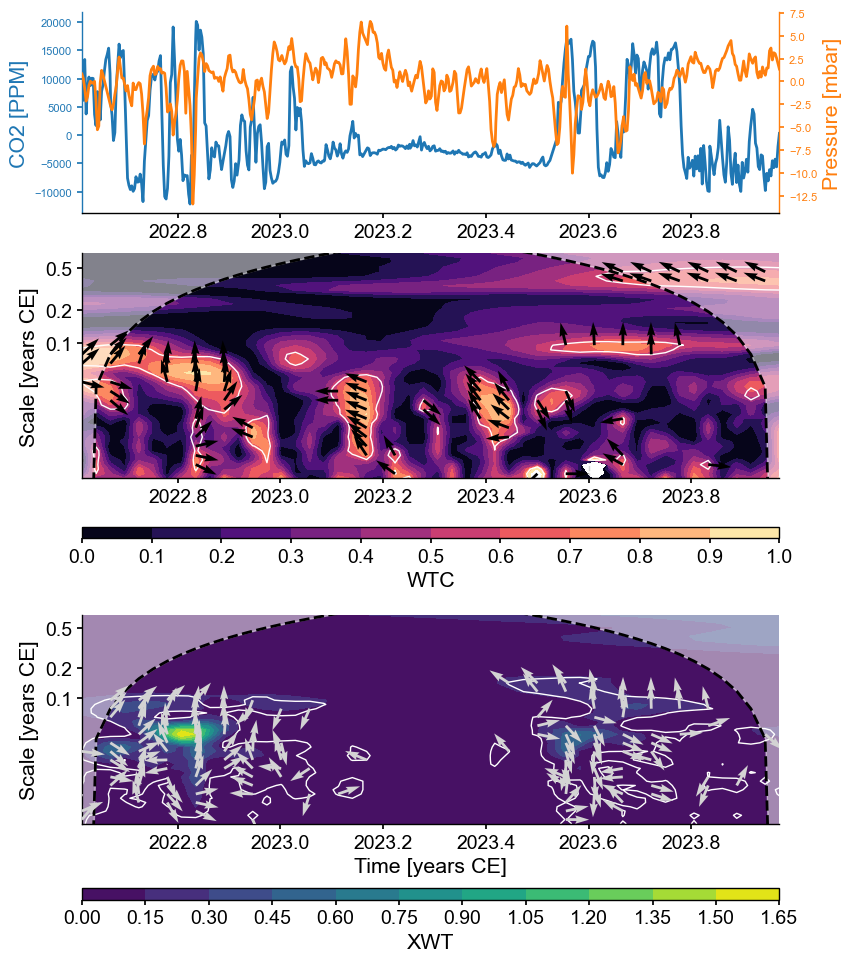

In [89]:
# SUMMARY OF ANALYSIS which INCLUDES WTC for area of common HIGH-POWER #
coh_sig.dashboard()
# another website that has details: 
# https://linked.earth/PyleoTutorials/notebooks/L2_wavelet_analysis.html

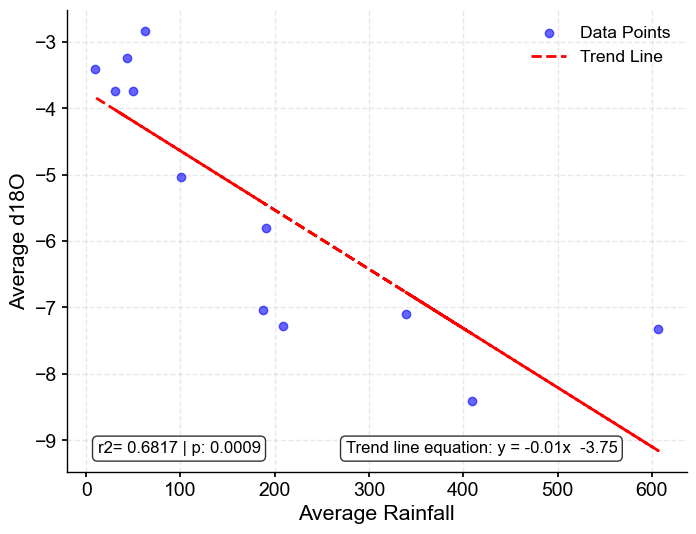

In [109]:
# Correlation Coefficient 

from scipy import stats
# 1. Import data  from manila_weighted excel sheet
mean_rain = [43.5625,30.7625,49.9625,61.9875,191.05,187.275,606.875,339.25,408.8625,208.3,100.15,9.05714286]
mean_d18o = [-3.245,-3.74375,-3.736,-2.8325,-5.811,-7.0311,-7.3177,-7.0922,-8.4122,-7.28,-5.03,-3.40875]
# 2. Calculate the correlation coefficient (r) and p-value
r_coefficient, p_value = stats.pearsonr(mean_rain, mean_d18o)
r2 = r_coefficient * r_coefficient
# 3. Calculate the trend line (1st degree polynomial = linear)
coefficients = np.polyfit(mean_rain, mean_d18o, 1)
trend_function = np.poly1d(coefficients)
# 4. Create the plot
plt.figure(figsize=(8, 6))
# Plot the raw data points
plt.scatter(mean_rain, mean_d18o, color="blue", alpha=0.6, label="Data Points")
# Plot the trend line
plt.plot(mean_rain, trend_function(mean_rain), color="red", linestyle="--", label="Trend Line")
# Add the correlation coefficient as text inside the chart
text_label = f"r2= {r2:.4f} | p: {p_value:.4f}"
plt.gca().text(0.05,0.05,text_label,transform=plt.gca().transAxes,fontsize=12,
verticalalignment="center",bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
text_label = f"Trend line equation: y = {coefficients[0]:.2f}x  {coefficients[1]:.2f}"
plt.gca().text(0.45,0.05,text_label,transform=plt.gca().transAxes,fontsize=12,
verticalalignment="center",bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
# Formatting the chart
plt.xlabel("Average Rainfall")
plt.ylabel("Average d18O")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
# Display the plot
plt.savefig(os.path.join(save_path, 'corr_coeff.eps'))
plt.show()